## Predicting At-Bat Outcomes with Markov Chains: Tactical Insights from MLB Data

8. In class, we'll briefly do presentations and criticize each other's work, and participation in your group's presentation and constructively critiquing the other groups' presentations accounts for the remaining 15/100 pts.

-------------------- Presentation Starts Here ------------------

### 1. Introduction:

- Baseball strategy hinges on pitch counts.
  - A 0‑2 count feels like survival for the batter, while 3‑0 feels like dominance for the pitcher.

- But how do these transitions actually unfold across thousands of at‑bats?

- And can we quantify the tug‑of‑war between batter tendencies and pitcher control?

### 2. Data:

- I used Statcast pitch‑by‑pitch data, which records balls, strikes, pitch type, and outcomes for every pitch

  - Each row is a single pitch with batter ID, pitcher ID, and the evolving count.”

- Some at‑bats are incomplete, some descriptions are ambiguous (‘hit_into_play’ vs. specific outcomes), and occasionally pitch sequences reset incorrectly.

  - I filtered out invalid back transitions and terminal states to ensure logical progression.

### 3. Methods:

- I built transition matrices:
  - Probability tables showing how counts evolve from one pitch to the next.
  - I computed these separately for each batter and pitcher, then compared them head‑to‑head.
  

Note : To avoid noise, I required a minimum number of transitions per player and validated only forward progressions.

### 4. Results:

- I found that certain pitchers suppress transitions to favorable hitter counts—for example, limiting 2‑0 to 3‑0 progressions.

- Conversely, aggressive batters push counts forward, increasing transitions from 1‑0 to 2‑0.

- The heatmaps reveal where batter tendencies clash with pitcher strategies: red cells show batter‑favored transitions, blue cells show pitcher suppression.”

Example:

- In one matchup, Batter A consistently advanced from 1‑0 to 2‑0, but Pitcher B reduced that probability by nearly 20%, forcing more 1‑1 counts instead.

- This highlights how pitchers can bend the statistical flow of an at‑bat.

### 5. Conclusion:

- My main finding is that pitch count transitions are not random—they reflect a measurable duel between batter patience and pitcher control.

- Future work could extend this to simulate entire games, cluster players by transition style, or integrate pitch type to refine matchup predictions.

-------------------- Presentation Ends Here --------------------



--------------------  Notebook Starts Here ---------------------

### Non-Parametric Model Options

In [ ]:
# installing dependencies / library

!pip install pybaseball

In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import random
import networkx as nx

from pybaseball import statcast
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder


In [30]:
# import MLB 2025 season data

data = statcast(start_dt='2025-02-20', end_dt='2025-11-01')


This is a large query, it may take a moment to complete


/usr/local/lib/python3.12/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates


  0%|          | 0/232 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

In [45]:
# quick preview

data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
43,FS,2025-11-01,92.1,-2.02,5.15,"Yamamoto, Yoshinobu",672386,808967,grounded_into_double_play,hit_into_play,...,<NA>,2.33,0.48,0.48,36.9,8.375233,-7.664043,17.979522,48.911447,37.014581
48,CU,2025-11-01,80.3,-1.7,5.45,"Yamamoto, Yoshinobu",672386,808967,NaN,called_strike,...,<NA>,4.85,-1.36,-1.36,48.1,<NA>,<NA>,<NA>,<NA>,<NA>
51,FC,2025-11-01,92.8,-1.91,5.24,"Yamamoto, Yoshinobu",672386,808967,NaN,foul,...,<NA>,2.04,-0.23,-0.23,39.1,14.162806,5.694338,22.383742,47.652657,23.055298
53,FS,2025-11-01,90.9,-1.97,5.26,"Yamamoto, Yoshinobu",680718,808967,walk,blocked_ball,...,<NA>,2.74,0.69,-0.69,40.1,<NA>,<NA>,<NA>,<NA>,<NA>
57,FS,2025-11-01,90.8,-2.02,5.27,"Yamamoto, Yoshinobu",680718,808967,NaN,ball,...,<NA>,2.3,0.23,-0.23,38.0,<NA>,<NA>,<NA>,<NA>,<NA>


In [46]:
# list columns in the data frame

data.columns.tolist()

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

2025 MLB Season Data :

- Spring Training : Feb 20 - Mar 25
- Regular Season : Mar 27 - Sep 28
- Playoffs : Sep 30 - Oct 20
- World Series : Oct 24 - Nov 1

In [41]:
# creating subsets

spr_data = data[(data['game_date'] >= '2025-02-20') & (data['game_date'] <= '2025-03-25')]
reg_data = data[(data['game_date'] >= '2025-03-27') & (data['game_date'] <= '2025-09-28')]
pf_data = data[(data['game_date'] >= '2025-09-30') & (data['game_date'] <= '2025-10-20')]
ws_data = data[(data['game_date'] >= '2025-10-24') & (data['game_date'] <= '2025-11-01')]


#### 1. Empirical Cumulative Distribution Functions (ECDF) :

  - Plots cumulative distribution of speeds.
    - Useful for comparing distributions across pitch types.





In [ ]:
# data subset

pitch_speeds = data['release_speed'].dropna()

pitch_speeds

,release_speed
43,92.1
48,80.3
51,92.8
53,90.9
57,90.8
...,...
4212,82.4
4398,94.0
4583,89.9
4784,94.5


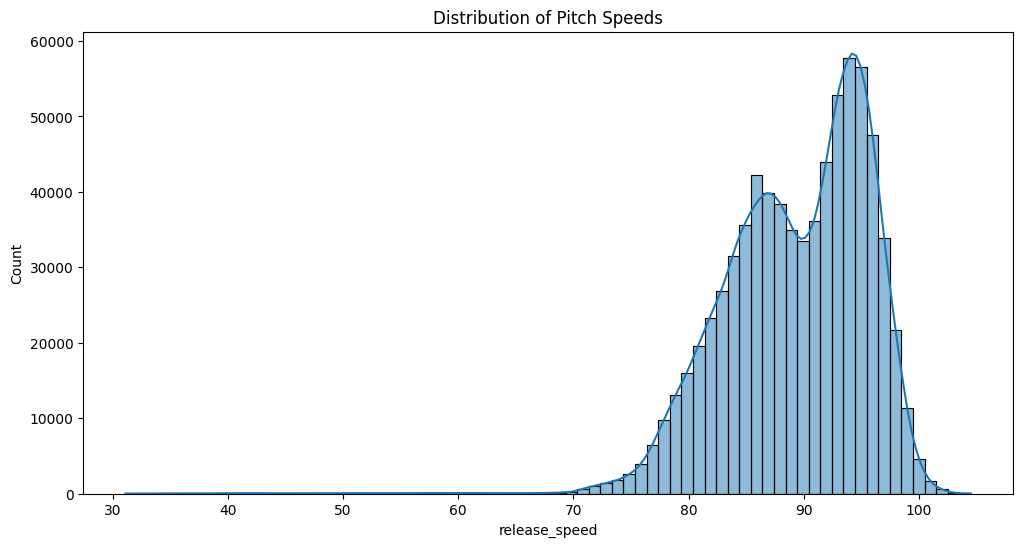

In [ ]:
# distribution of pitch speeds across all pitches

plt.figure(figsize=(12, 6))
sns.histplot(pitch_speeds, binwidth=1, kde=True)


plt.xlabel("release_speed")
plt.ylabel("Count")
plt.title("Distribution of Pitch Speeds")

plt.show()

Interpretation :

- Right-skewed distribution:
  - The tail extending leftward toward lower speeds (down to ~30 mph) indicates occasional off-speed pitches like curveballs or changeups. These are thrown less frequently but are strategically important.

- Concentration range:
  - The majority of pitches fall between 85 and 100 mph, suggesting that most pitchers operate within this velocity band. This range includes fastballs, cutters, and some hard sliders.

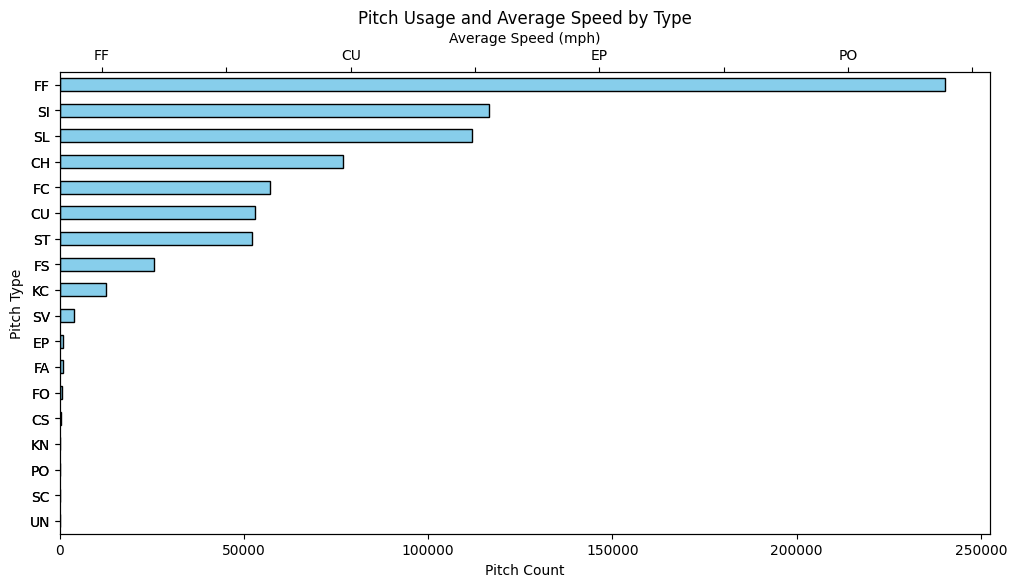

In [ ]:

# Prepare summary sorted by count descending

pitch_summary = data.groupby("pitch_type").release_speed.agg(["count","mean"])
pitch_summary["percent"] = pitch_summary["count"]/pitch_summary["count"].sum()*100
pitch_summary = pitch_summary.sort_values("count", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Horizontal bar chart for counts
pitch_summary["count"].plot(kind="barh", ax=ax1, color="skyblue", edgecolor="black")

# Invert y-axis so largest count is at the top
ax1.invert_yaxis()

# Secondary axis for average speed
ax2 = ax1.twiny()
pitch_summary["mean"].plot(kind="line", ax=ax2, color="red", marker="o")

# Labels
ax1.set_xlabel("Pitch Count")
ax2.set_xlabel("Average Speed (mph)")
ax1.set_ylabel("Pitch Type")
plt.title("Pitch Usage and Average Speed by Type")

plt.show()

In [ ]:
# split by pitch_type

data.groupby("pitch_type").release_speed.agg(["count","mean"]).assign(percent=lambda x: x["count"]/x["count"].sum()*100).sort_values("count", ascending=False)

,count,mean,percent
pitch_type,,,
FF,240426,94.501488,31.946011
SI,116470,93.815395,15.475664
SL,111784,86.118717,14.853023
CH,76941,85.847063,10.223345
FC,57063,89.711061,7.582105
CU,52976,79.716453,7.039055
ST,52146,82.496316,6.928771
FS,25474,86.476643,3.384795
KC,12571,82.9268,1.670341


In [ ]:
# FF – Four-Seam Fastball
# SI – Sinker
# SL – Slider
# CH – Changeup
# FC – Cutter
# CU – Curveball
# ST – Sweeper
# FS – Splitter
# KC – Knuckle Curve
# SV – Slurve
# EP – Eephus Pitch
# FA – Fastball
# FO – Forkball
# CS – Called Strike
# KN – Knuckleball
# PO – Pitchout
# SC – Screwball
# UN – Unknown


In [ ]:
# define ecdf function

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y


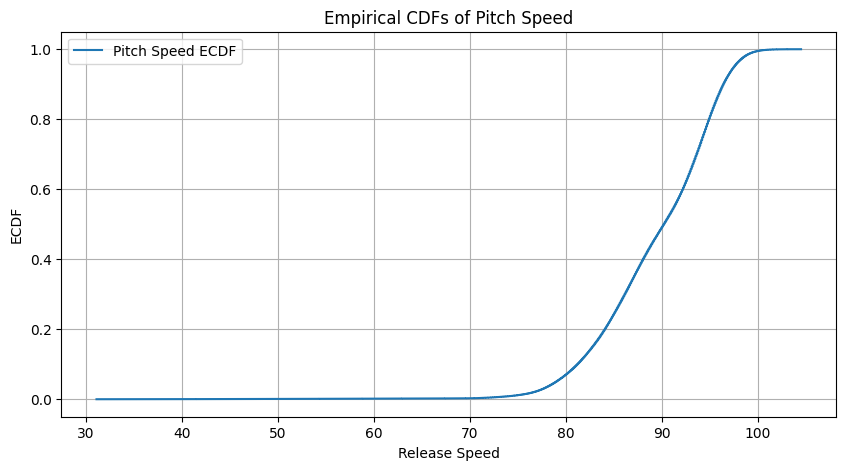

In [ ]:
x_ev, y_ev = ecdf(pitch_speeds)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_ev, y_ev, label='Pitch Speed ECDF')
plt.xlabel('Release Speed')
plt.ylabel('ECDF')
plt.legend()
plt.title('Empirical CDFs of Pitch Speed')

plt.grid(True)
plt.show()

Plot speed vs. cumulative probability :

- X-axis (Release Speed): This represents the speed at which pitches are thrown, likely in miles per hour.

- Y-axis (ECDF): This shows the proportion of pitches thrown at or below each speed.

Interpretation :

  - Steep rise between 90–100 mph: This means a large share of pitches fall in this range.
    - For example, if the ECDF hits 0.8 at 95 mph, it means 80% of pitches are thrown at or below 95 mph.

  - Flat regions: These indicate speed ranges where few pitches are thrown.

  - Curve shape: A sharp vertical climb means a dense cluster of values (common speeds); a gradual slope means more spread-out speeds.

### Bootstrap Sampling from ECDF

In [ ]:
def bootstrap_ecdf_band(data, n_boot=200, grid_size=500):
    """
    Compute bootstrap ECDF confidence bands with reduced memory.
    """
    # Define a smaller grid of x values
    x = np.linspace(np.min(data), np.max(data), grid_size)
    ecdfs = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        sample_sorted = np.sort(sample)
        ecdf = np.arange(1, len(sample_sorted)+1) / len(sample_sorted)
        ecdfs.append(np.interp(x, sample_sorted, ecdf))

    ecdfs = np.array(ecdfs)
    lower = np.percentile(ecdfs, 2.5, axis=0)
    upper = np.percentile(ecdfs, 97.5, axis=0)
    return x, lower, upper


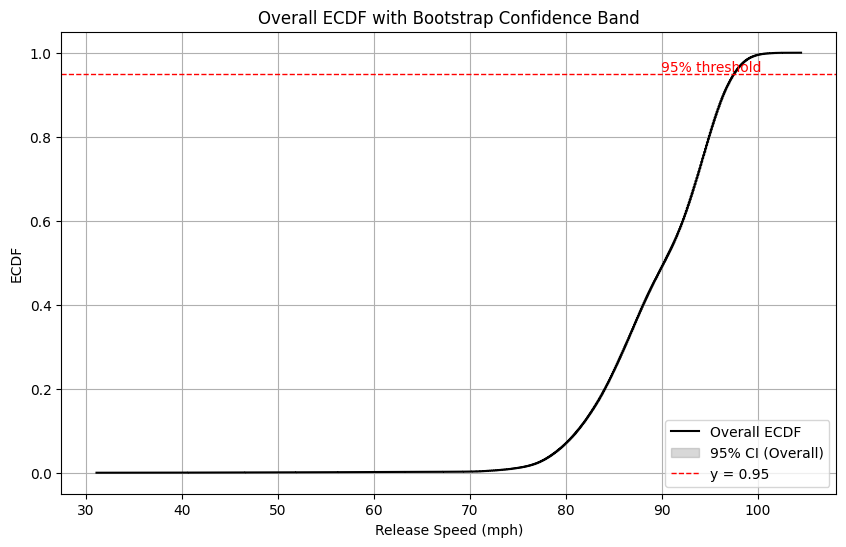

In [ ]:
# Overall ECDF with bootstrap confidence band
speeds_all = data["release_speed"].dropna().values
x = np.sort(speeds_all)
y = np.arange(1, len(x)+1) / len(x)
x_band, lower, upper = bootstrap_ecdf_band(speeds_all)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label="Overall ECDF", color="black")
plt.fill_between(x_band, lower, upper, color="gray", alpha=0.3, label="95% CI (Overall)")

# Add horizontal reference line at y = 0.95
plt.axhline(0.95, color='red', linestyle='--', linewidth=1, label='y = 0.95')
plt.text(x_band[int(len(x_band)*0.8)], 0.955, "95% threshold", color='red')

plt.xlabel("Release Speed (mph)")
plt.ylabel("ECDF")
plt.title("Overall ECDF with Bootstrap Confidence Band")
plt.legend()
plt.grid(True)
plt.show()

#### Bootstrap Percentiles Confidence Interval

In [ ]:
def bootstrap_percentiles(data, percentiles=[25, 50, 75], n_boot=1000, ci=90):
    """
    Bootstrap confidence intervals for given percentiles.
    Returns a dictionary: {percentile: (lower, estimate, upper)}
    """
    results = {}
    alpha = (100 - ci) / 2

    for p in percentiles:
        boot_stats = []
        for _ in range(n_boot):
            sample = np.random.choice(data, size=len(data), replace=True)
            boot_stats.append(np.percentile(sample, p))

        lower = np.percentile(boot_stats, alpha)
        upper = np.percentile(boot_stats, 100 - alpha)
        estimate = np.percentile(data, p)
        results[p] = (lower, estimate, upper)

    return results


In [ ]:
speeds_all = data["release_speed"].dropna().values
ci_results = bootstrap_percentiles(speeds_all, percentiles=[25, 50, 75], n_boot=1000, ci=90)

for p, (low, est, high) in ci_results.items():
    print(f"{p}th percentile: {est:.2f} mph (90% CI: {low:.2f} – {high:.2f})")


25th percentile: 85.20 mph (90% CI: 85.10 – 85.20)
50th percentile: 90.20 mph (90% CI: 90.20 – 90.20)
75th percentile: 94.30 mph (90% CI: 94.30 – 94.30)


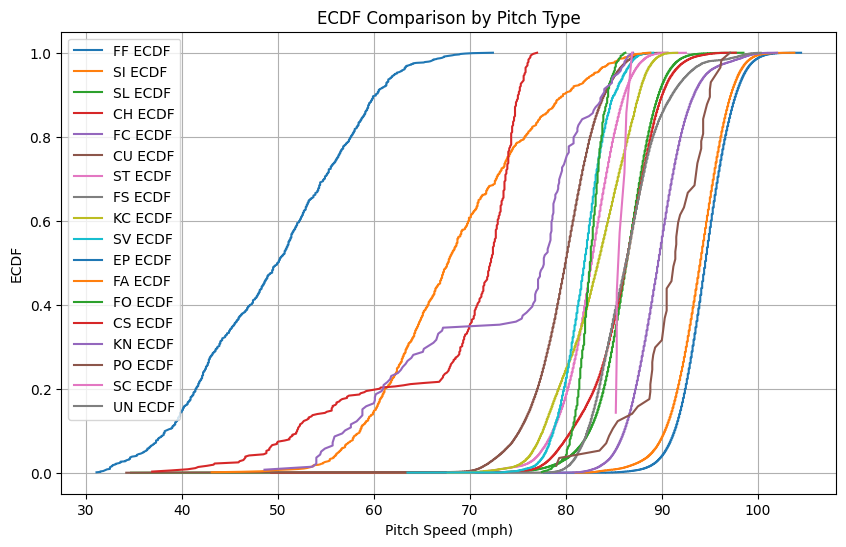

In [ ]:
# Select pitch types to compare
pitch_types = ['FF', 'SI', 'SL', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV','EP','FA','FO','CS','KN','PO','SC','UN']

# FF – Four-Seam Fastball
# SI – Sinker
# SL – Slider
# CH – Changeup
# FC – Cutter
# CU – Curveball
# ST – Sweeper
# FS – Splitter
# KC – Knuckle Curve
# SV – Slurve
# EP – Eephus Pitch
# FA – Fastball
# FO – Forkball
# CS – Called Strike
# KN – Knuckleball
# PO – Pitchout
# SC – Screwball
# UN – Unknown


plt.figure(figsize=(10, 6))
for pt in pitch_types:
    speeds = data[data['pitch_type'] == pt]['release_speed']
    x, y = ecdf(speeds)
    plt.plot(x, y, label=f'{pt} ECDF')

plt.xlabel('Pitch Speed (mph)')
plt.ylabel('ECDF')
plt.title('ECDF Comparison by Pitch Type')
plt.legend()
plt.grid(True)
plt.show()

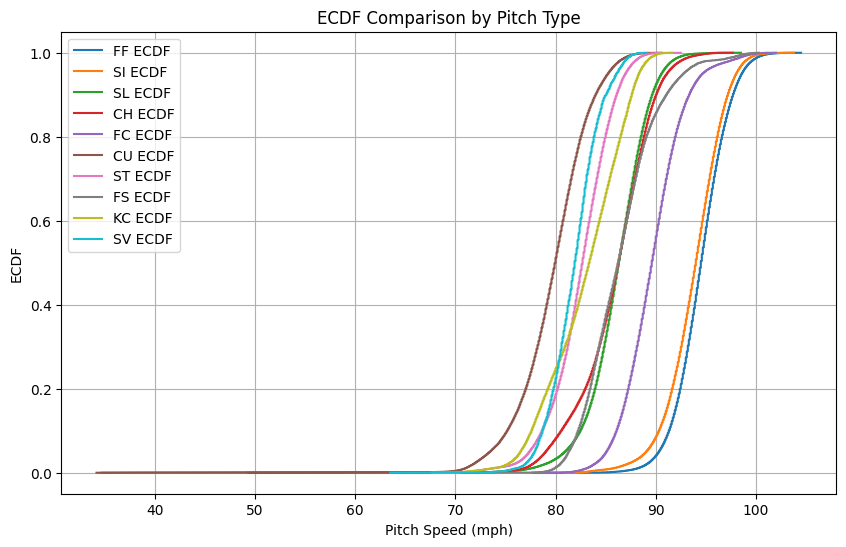

In [ ]:
# Select pitch types to compare
pitch_types = ['FF', 'SI', 'SL', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC','SV']

plt.figure(figsize=(10, 6))
for pt in pitch_types:
    speeds = data[data['pitch_type'] == pt]['release_speed']
    x, y = ecdf(speeds)
    plt.plot(x, y, label=f'{pt} ECDF')

plt.xlabel('Pitch Speed (mph)')
plt.ylabel('ECDF')
plt.title('ECDF Comparison by Pitch Type')
plt.legend()
plt.grid(True)
plt.show()

Interpretation :

- Steeper curves (e.g., FF, SI): These indicate tightly clustered pitch speeds — most fastballs are thrown within a narrow velocity band.

- Flatter curves (e.g., CU, CH): These suggest more variation in speed — off-speed pitches tend to have broader distributions.

- Left-shifted curves: Pitch types like CU and CH start rising earlier, meaning they’re generally slower.

- Right-shifted curves: FF and SI rise later, showing they dominate the higher velocity range.

#### ECDF Comparison across pitch type with Bootstrap Band

In [ ]:
def bootstrap_ecdf_band(data, n_boot=200, grid_size=500):
    """
    Compute bootstrap ECDF confidence bands with reduced memory.
    """
    x = np.linspace(np.min(data), np.max(data), grid_size)
    ecdfs = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        sample_sorted = np.sort(sample)
        ecdf = np.arange(1, len(sample_sorted)+1) / len(sample_sorted)
        ecdfs.append(np.interp(x, sample_sorted, ecdf))

    ecdfs = np.array(ecdfs)
    lower = np.percentile(ecdfs, 2.5, axis=0)
    upper = np.percentile(ecdfs, 97.5, axis=0)
    return x, lower, upper

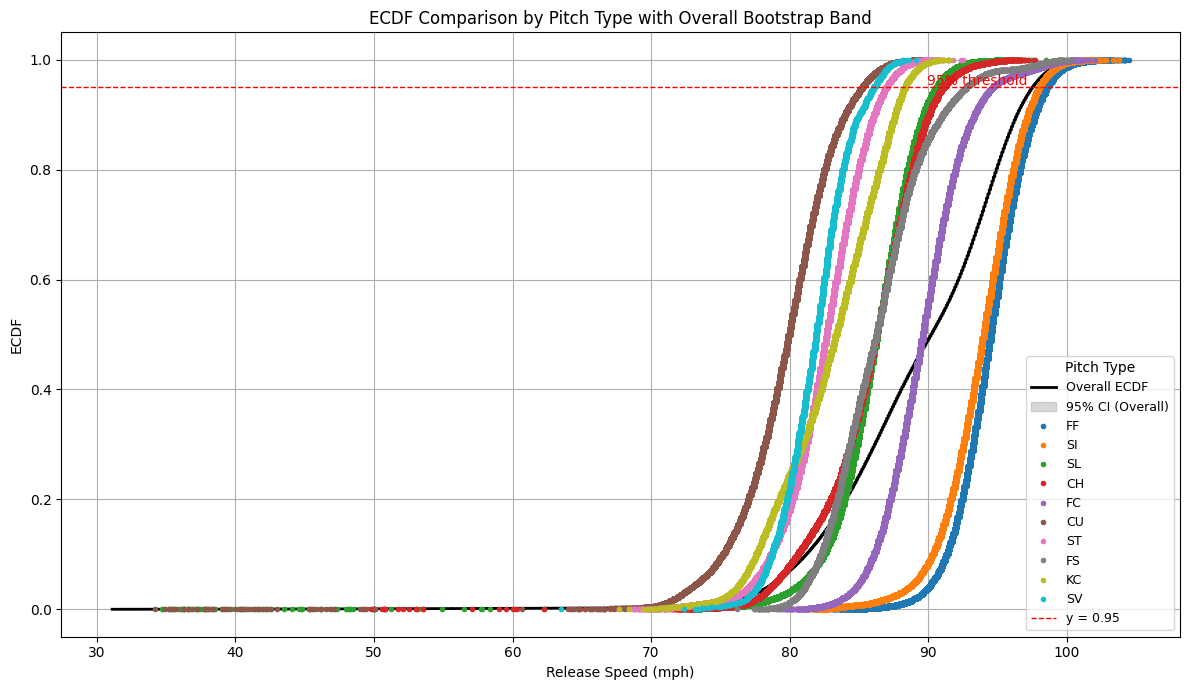

In [ ]:
# Overall ECDF with bootstrap confidence band
speeds_all = data["release_speed"].dropna().values
x = np.sort(speeds_all)
y = np.arange(1, len(x)+1) / len(x)
x_band, lower, upper = bootstrap_ecdf_band(speeds_all)

# Define pitch types to compare
pitch_types = ['FF', 'SI', 'SL', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV']

plt.figure(figsize=(12, 7))

# Plot overall ECDF and bootstrap band
plt.plot(x, y, label="Overall ECDF", color="black", linewidth=2)
plt.fill_between(x_band, lower, upper, color="gray", alpha=0.3, label="95% CI (Overall)")

# Overlay ECDFs for each pitch type
for pt in pitch_types:
    speeds = data.loc[data["pitch_type"] == pt, "release_speed"].dropna().values
    if len(speeds) == 0:
        continue
    x_pt = np.sort(speeds)
    y_pt = np.arange(1, len(x_pt)+1) / len(x_pt)
    plt.plot(x_pt, y_pt, linestyle="none", marker=".", label=pt)

# Add horizontal reference line at y = 0.95
plt.axhline(0.95, color='red', linestyle='--', linewidth=1, label='y = 0.95')
plt.text(x_band[int(len(x_band)*0.8)], 0.955, "95% threshold", color='red')

plt.xlabel("Release Speed (mph)")
plt.ylabel("ECDF")
plt.title("ECDF Comparison by Pitch Type with Overall Bootstrap Band")
plt.legend(title="Pitch Type", loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation :

Each pitch type’s ECDF curve shows how its speed distribution compares to the overall:

- Fastballs (FF, FT)
  - Right-shifted and steep: These pitches dominate the high-speed range.
  - Their ECDF curves rise sharply near 90–100 mph, meaning most fastballs are thrown in that band.
  - They closely hug the upper end of the overall ECDF.

- Off-Speed Pitches (CH, CU, KC, SV)
  - Left-shifted and flatter: These pitches are slower and more variable.
  - Their ECDFs start rising earlier (around 70–80 mph), indicating lower speeds.
  - The flatter slope means more spread — speeds vary more within these types.

- Breaking Balls (SL, FC, ST)
  - Intermediate profiles: Sliders and cutters sit between fastballs and off-speed pitches.
  - Their ECDFs rise in the 80–90 mph range, showing moderate speed and variability.

#### Bootstrap Percentiles by Pitch Type

In [ ]:
def bootstrap_percentiles_by_pitch(data, pitch_col="pitch_type", speed_col="release_speed",
                                   percentiles=[25, 50, 75], n_boot=1000, ci=90):
    """
    Compute bootstrap percentile confidence intervals for each pitch type.

    Returns a dictionary:
    {pitch_type: {percentile: (lower, estimate, upper)}}
    """
    results = {}
    alpha = (100 - ci) / 2
    pitch_types = data[pitch_col].dropna().unique()

    for pt in pitch_types:
        speeds = data.loc[data[pitch_col] == pt, speed_col].dropna().values
        if len(speeds) == 0:
            continue

        pt_result = {}
        for p in percentiles:
            boot_stats = [np.percentile(np.random.choice(speeds, size=len(speeds), replace=True), p)
                          for _ in range(n_boot)]
            lower = np.percentile(boot_stats, alpha)
            upper = np.percentile(boot_stats, 100 - alpha)
            estimate = np.percentile(speeds, p)
            pt_result[p] = (lower, estimate, upper)

        results[pt] = pt_result

    return results


In [ ]:
ci_by_pitch = bootstrap_percentiles_by_pitch(data, percentiles=[25, 50, 75], n_boot=500, ci=90)

for pt in sorted(ci_by_pitch.keys()):
    print(f"\nPitch Type: {pt}")
    for p, (low, est, high) in ci_by_pitch[pt].items():
        print(f"  {p}th percentile: {est:.2f} mph (90% CI: {low:.2f} – {high:.2f})")



Pitch Type: CH
  25th percentile: 83.80 mph (90% CI: 83.70 – 83.80)
  50th percentile: 86.30 mph (90% CI: 86.30 – 86.30)
  75th percentile: 88.40 mph (90% CI: 88.30 – 88.40)

Pitch Type: CS
  25th percentile: 67.90 mph (90% CI: 66.90 – 68.90)
  50th percentile: 72.20 mph (90% CI: 71.80 – 72.50)
  75th percentile: 74.00 mph (90% CI: 73.80 – 74.30)

Pitch Type: CU
  25th percentile: 77.70 mph (90% CI: 77.60 – 77.70)
  50th percentile: 80.00 mph (90% CI: 79.90 – 80.00)
  75th percentile: 82.00 mph (90% CI: 82.00 – 82.10)

Pitch Type: EP
  25th percentile: 42.50 mph (90% CI: 42.10 – 42.95)
  50th percentile: 50.00 mph (90% CI: 49.20 – 50.70)
  75th percentile: 56.20 mph (90% CI: 55.50 – 56.75)

Pitch Type: FA
  25th percentile: 62.50 mph (90% CI: 62.10 – 63.00)
  50th percentile: 67.70 mph (90% CI: 67.20 – 68.30)
  75th percentile: 73.90 mph (90% CI: 73.50 – 74.50)

Pitch Type: FC
  25th percentile: 87.70 mph (90% CI: 87.70 – 87.70)
  50th percentile: 89.60 mph (90% CI: 89.60 – 89.60)
  7

Interpretation :

- High-Velocity Pitch Types :
  - FF (Four-seam fastball):
    - Median: 94.5 mph
    - Tight CI: [94.5 – 94.5] → extremely consistent
    - 75th percentile: 96.2 mph → elite velocity

- Low-Velocity & Specialty Pitches
  - CS (Slow Curve), FA (Fosh), KN (Knuckleball):
    - Medians: 72.2, 67.7, and 77.7 mph respectively
    - Wider CIs → more unpredictable movement

Kernel Density Estimation (KDE): Smooth estimate of the probability density function. Good for visualizing the shape of the speed distribution.

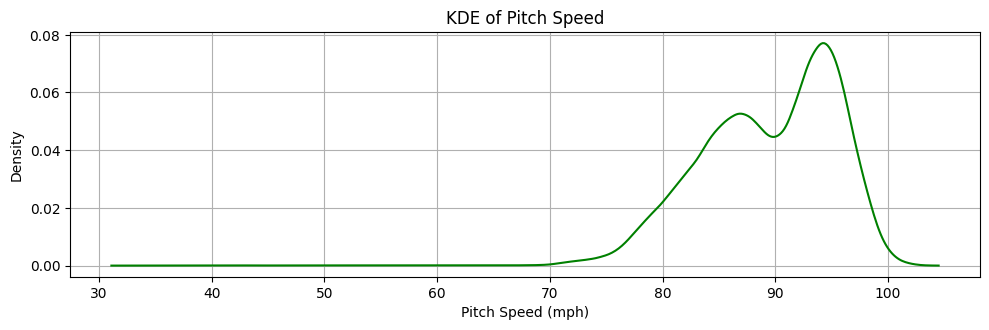

In [ ]:
# Step 3: Compute KDE
kde = gaussian_kde(pitch_speeds)
x_kde = np.linspace(min(pitch_speeds), max(pitch_speeds), 500)
y_kde = kde(x_kde)


# KDE
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 2)
plt.plot(x_kde, y_kde, color='green')
plt.title('KDE of Pitch Speed')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Density')
plt.grid(True)

plt.tight_layout()
plt.show()

Key Insights from KDE of Pitch Speeds

- Smooth distribution: KDE provides a continuous estimate of pitch speed density, avoiding the binning artifacts of histograms.

- Primary peak near 90 mph: Indicates the most common pitch speed range — likely dominated by fastballs.

- Secondary peak above 95 mph: Suggests a subset of high-velocity pitches (e.g., elite fastballs or cutters).

- Low density below 70 mph: Very few pitches are thrown at these speeds — mostly specialty or novelty pitches.

- Steep rise between 70–90 mph: Reflects the transition zone where off-speed pitches give way to fastballs.

- Multimodal structure: Multiple peaks hint at distinct pitch families within the dataset.

- No hard boundaries: KDE shows overlapping distributions, useful for identifying deceptive velocity zones.

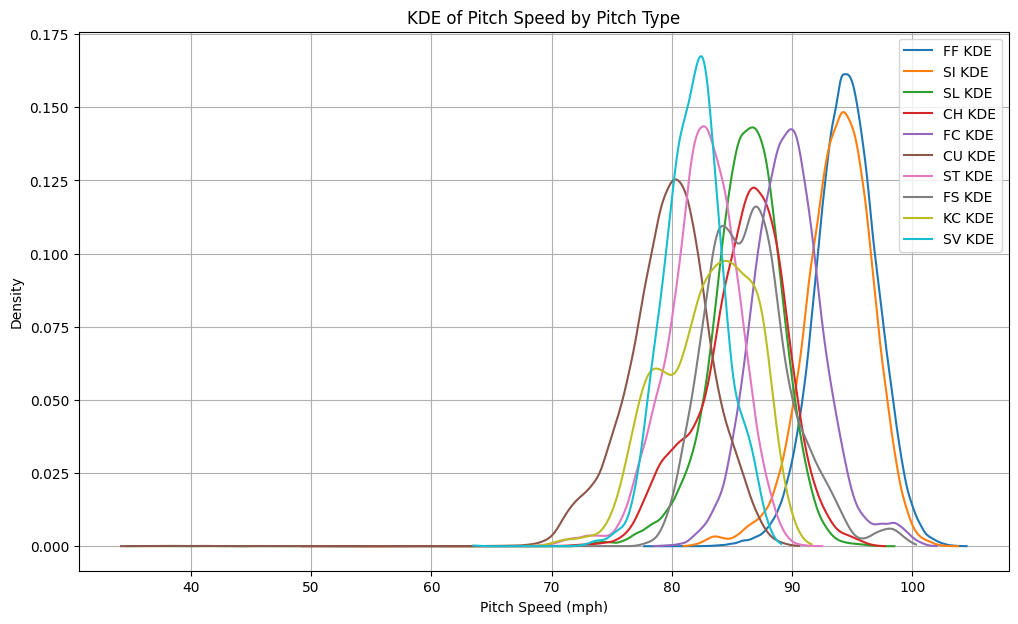

In [ ]:
plt.figure(figsize=(12, 7))

for pt in pitch_types:
    # Select speeds for this pitch type and drop NaNs/Infs
    speeds = data.loc[data['pitch_type'] == pt, 'release_speed']
    speeds = speeds.replace([np.inf, -np.inf], np.nan).dropna()

    if len(speeds) > 1:  # need at least 2 points for KDE
        kde = gaussian_kde(speeds)
        x_vals = np.linspace(speeds.min(), speeds.max(), 500)
        y_vals = kde(x_vals)
        plt.plot(x_vals, y_vals, label=f'{pt} KDE')

plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Density')
plt.title('KDE of Pitch Speed by Pitch Type')
plt.legend()
plt.grid(True)
plt.show()

Key Takeaways :

- FF (Four-seam fastball)
  - Sharp peak near 95–97 mph
  - Very narrow spread → high velocity, high consistency


- CU (Curveball), KC (Knuckle Curve), SV (Sweeper)

  - Peaks between 75–82 mph
  - Broader curves → more variability in speed
  - These are movement-heavy pitches with lower velocity


In [ ]:
n_boot = 1000
results = {}

for pt in pitch_types:
    speeds = data.loc[data['pitch_type'] == pt, 'release_speed']
    speeds = speeds.replace([np.inf, -np.inf], np.nan).dropna().values  # drop NaNs/Infs

    if len(speeds) > 1:  # need at least 2 values for bootstrap
        boot_medians = [np.median(np.random.choice(speeds, size=len(speeds), replace=True)) for _ in range(n_boot)]
        boot_p90s = [np.percentile(np.random.choice(speeds, size=len(speeds), replace=True), 90) for _ in range(n_boot)]
        ci_median = np.percentile(boot_medians, [2.5, 97.5])
        ci_p90 = np.percentile(boot_p90s, [2.5, 97.5])
        results[pt] = {
            'median_CI': ci_median,
            'p90_CI': ci_p90
        }
    else:
        results[pt] = {
            'median_CI': [np.nan, np.nan],
            'p90_CI': [np.nan, np.nan]
        }

# Display results
for pt, stats in results.items():
    print(f"{pt} - Median CI: {stats['median_CI'][0]:.2f} to {stats['median_CI'][1]:.2f} mph")
    print(f"{pt} - 90th Percentile CI: {stats['p90_CI'][0]:.2f} to {stats['p90_CI'][1]:.2f} mph\n")


FF - Median CI: 94.50 to 94.50 mph
FF - 90th Percentile CI: 97.70 to 97.70 mph

SI - Median CI: 94.00 to 94.00 mph
SI - 90th Percentile CI: 97.20 to 97.20 mph

SL - Median CI: 86.30 to 86.30 mph
SL - 90th Percentile CI: 89.60 to 89.70 mph

CH - Median CI: 86.20 to 86.30 mph
CH - 90th Percentile CI: 90.00 to 90.10 mph

FC - Median CI: 89.60 to 89.60 mph
FC - 90th Percentile CI: 93.30 to 93.40 mph

CU - Median CI: 79.90 to 80.00 mph
CU - 90th Percentile CI: 84.00 to 84.10 mph

ST - Median CI: 82.60 to 82.70 mph
ST - 90th Percentile CI: 86.10 to 86.10 mph

FS - Median CI: 86.20 to 86.30 mph
FS - 90th Percentile CI: 91.00 to 91.20 mph

KC - Median CI: 83.30 to 83.50 mph
KC - 90th Percentile CI: 87.50 to 87.70 mph

SV - Median CI: 81.80 to 82.00 mph
SV - 90th Percentile CI: 84.80 to 85.20 mph



### Comparative: Stratified by pitch type, pitcher, and count

Stratify by the pitcher

In [30]:
# Step 1: Choose pitchers to analyze

# Count pitches per pitcher ID
pitch_counts = data['pitcher'].value_counts().reset_index()
pitch_counts.columns = ['pitcher_id', 'pitch_count']

# If your dataset has pitcher names in a column (e.g., 'player_name')
pitcher_info = data[['pitcher', 'player_name']].drop_duplicates()
pitcher_info.columns = ['pitcher_id', 'player_name']

# Merge counts with names
pitcher_stats = pitch_counts.merge(pitcher_info, on='pitcher_id', how='left')

# Sort in descending order
pitcher_stats = pitcher_stats.sort_values(by='pitch_count', ascending=False)

print(pitcher_stats)


      pitcher_id  pitch_count        player_name
0         592332         3549     Gausman, Kevin
1         642547         3533    Peralta, Freddy
2         607074         3452      Rodón, Carlos
3         657277         3434        Webb, Logan
4         676979         3430   Crochet, Garrett
...          ...          ...                ...
1196      656716            2    McKinstry, Zach
1199      689233            2        Wepf, Lucas
1198      691669            2      Sosa, Gabriel
1200      700072            1      Rivera, Yaqui
1201      676502            1  Phansalkar, Roman

[1202 rows x 3 columns]


In [11]:
# Statcast pitcher IDs for the requested players
pitcher_lookup = {
    808967: "Yoshinobu Yamamoto",
    694973: "Paul Skenes",
    669373: "Tarik Skubal",
    694819: "Jacob Misiorowski"
}

# Step 1: Count pitches per pitcher ID
pitch_counts = data['pitcher'].value_counts().reset_index()
pitch_counts.columns = ['pitcher_id', 'pitch_count']

# Step 2: Filter only the requested pitchers
pitch_counts = pitch_counts[pitch_counts['pitcher_id'].isin(pitcher_lookup.keys())]

# Step 3: Map IDs to names
pitch_counts['player_name'] = pitch_counts['pitcher_id'].map(pitcher_lookup)

# Step 4: Sort in descending order
pitch_counts = pitch_counts.sort_values(by='pitch_count', ascending=False)

pitchers = list(pitcher_lookup.keys())

print(pitch_counts)




    pitcher_id  pitch_count         player_name
5       808967         3315  Yoshinobu Yamamoto
8       669373         3220        Tarik Skubal
18      694973         3133         Paul Skenes
166     694819         1348   Jacob Misiorowski


In [36]:
# Step 2: Bootstrap for each pitcher
for pid in pitchers:
    speeds = data[data['pitcher'] == pid]['release_speed'].dropna().values

    boot_medians = [np.median(np.random.choice(speeds, size=len(speeds), replace=True)) for _ in range(n_boot)]
    boot_p90s = [np.percentile(np.random.choice(speeds, size=len(speeds), replace=True), 90) for _ in range(n_boot)]

    ci_median = np.percentile(boot_medians, [2.5, 97.5])
    ci_p90 = np.percentile(boot_p90s, [2.5, 97.5])

    # Use lookup dictionary to get name
    name = pitcher_lookup.get(pid, f"Unknown ({pid})")

    print(f"{name} (ID {pid}) - Median CI: {ci_median[0]:.2f} to {ci_median[1]:.2f} mph")
    print(f"{name} (ID {pid}) - 90th Percentile CI: {ci_p90[0]:.2f} to {ci_p90[1]:.2f} mph\n")

Yoshinobu Yamamoto (ID 808967) - Median CI: 91.90 to 92.30 mph
Yoshinobu Yamamoto (ID 808967) - 90th Percentile CI: 96.00 to 96.20 mph

Paul Skenes (ID 694973) - Median CI: 94.60 to 96.30 mph
Paul Skenes (ID 694973) - 90th Percentile CI: 98.70 to 98.80 mph

Tarik Skubal (ID 669373) - Median CI: 95.30 to 95.90 mph
Tarik Skubal (ID 669373) - 90th Percentile CI: 98.51 to 98.80 mph

Jacob Misiorowski (ID 694819) - Median CI: 96.60 to 97.70 mph
Jacob Misiorowski (ID 694819) - 90th Percentile CI: 100.60 to 100.90 mph



### Pitch Speed by Pitch Type Across Pitchers

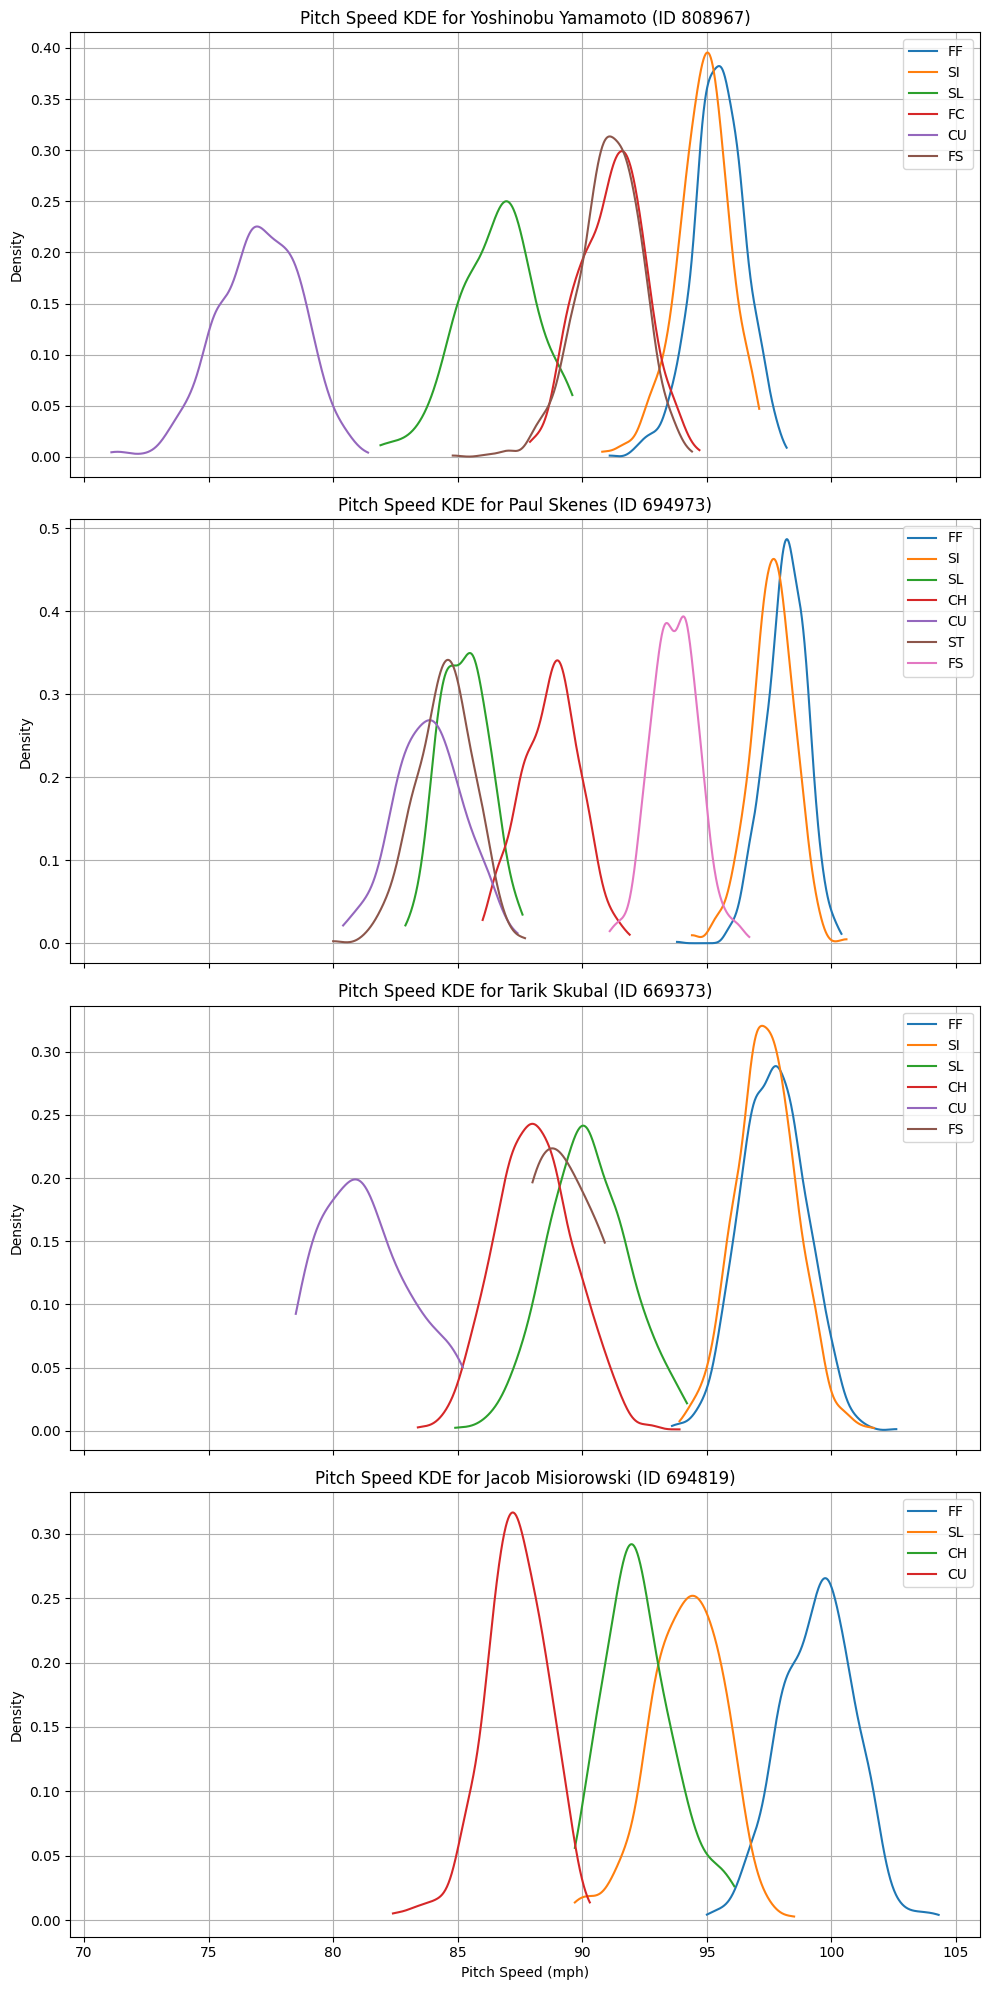

In [38]:
# Plot setup
fig, axes = plt.subplots(len(pitchers), 1, figsize=(10, 5 * len(pitchers)), sharex=True)

for i, pid in enumerate(pitchers):
    ax = axes[i]
    pitcher_df = data[data['pitcher'] == pid]
    for pt in pitch_types:
        speeds = pitcher_df[pitcher_df['pitch_type'] == pt]['release_speed']
        if len(speeds) > 1:
            kde = gaussian_kde(speeds)
            x_vals = np.linspace(min(speeds), max(speeds), 500)
            y_vals = kde(x_vals)
            ax.plot(x_vals, y_vals, label=pt)

    # Use lookup dictionary to display name if available
    name = pitcher_lookup.get(pid, f"Unknown ({pid})")
    ax.set_title(f'Pitch Speed KDE for {name} (ID {pid})')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True)

plt.xlabel('Pitch Speed (mph)')
plt.tight_layout()
plt.show()

Pitcher-by-Pitcher Breakdown

- Yoshinobu Yamamoto (ID 808967)
  - Pitch types: FF, SI, SL, FC, CU, FS
  - Fastball (FF) peaks around 95–96 mph, with a tight distribution
  - Splitter (FS) and Curveball (CU) show clear separation, peaking around 85–88 mph and 78–80 mph, respectively.

  - Insight:
    - Yamamoto has a well-separated arsenal. His offspeed pitches don’t bleed into fastball territory, which helps with deception.

- Paul Skenes (ID 694973)
  - Pitch types: FF, SI, SL, CH, CU, ST, FS
  - FF and FS both peak near 100 mph, showing elite velocity.
  - Slider (SL) and Changeup (CH) sit around 90–93 mph, with the Curveball (CU) dipping to low 80s.
  
  - Insight:
    - Skenes throws hard across the board. His offspeed pitches are relatively firm, which may reduce velocity separation but increase tunneling.

- Tarik Skubal (ID 669373)
  - Pitch types: FF, SI, SL, CH, CU, FS
  - FF peaks around 96–97 mph, with a broad base.
  - Slider and Changeup are in the mid-80s, and Curveball around 78–80 mph.
  
  - Insight:
    - Skubal has a classic velocity spread. His offspeed pitches are slower and well-separated from his fastball, which supports swing-and-miss potential.


- Jacob Misiorowski (ID 694819)
  - Pitch types: FF, SL, CH, CU
  - FF peaks near 100 mph, with a sharp distribution.
  - Slider around 93 mph, Changeup around 91 mph, and Curveball near 83 mph.
  
  - Insight:
    - Misiorowski’s offspeed pitches are unusually firm. His slider and changeup overlap in speed, which may affect differentiation unless movement profiles are distinct.

Pitch Type Usage Across Counts

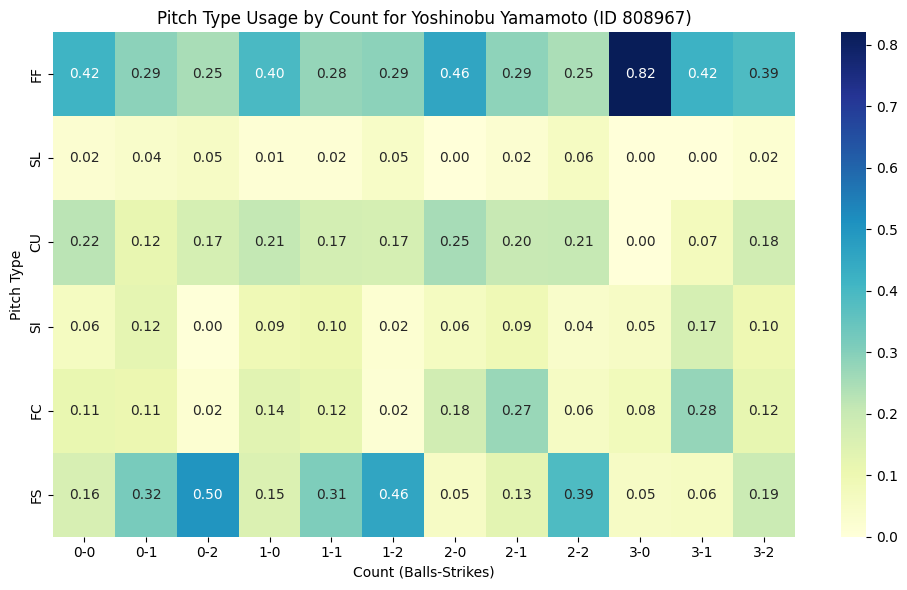

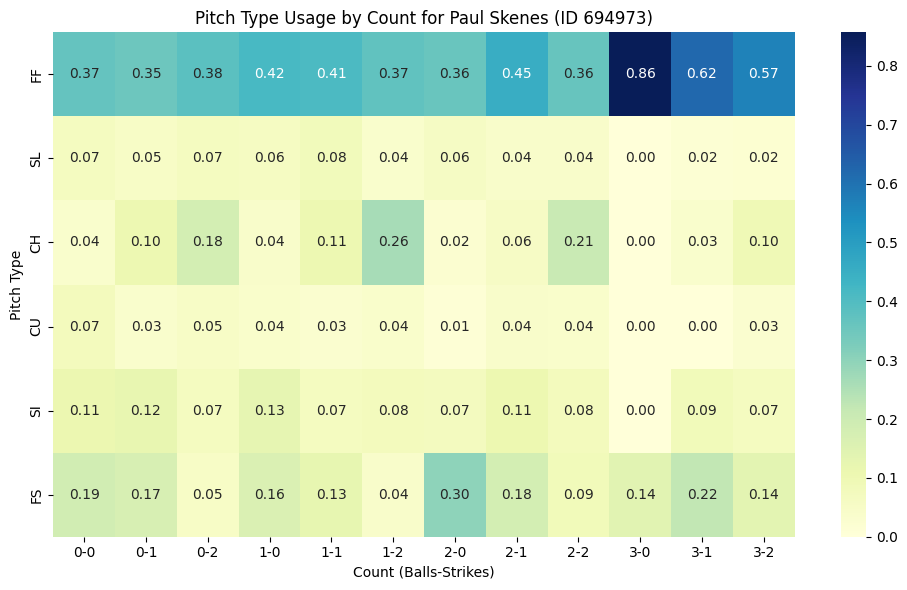

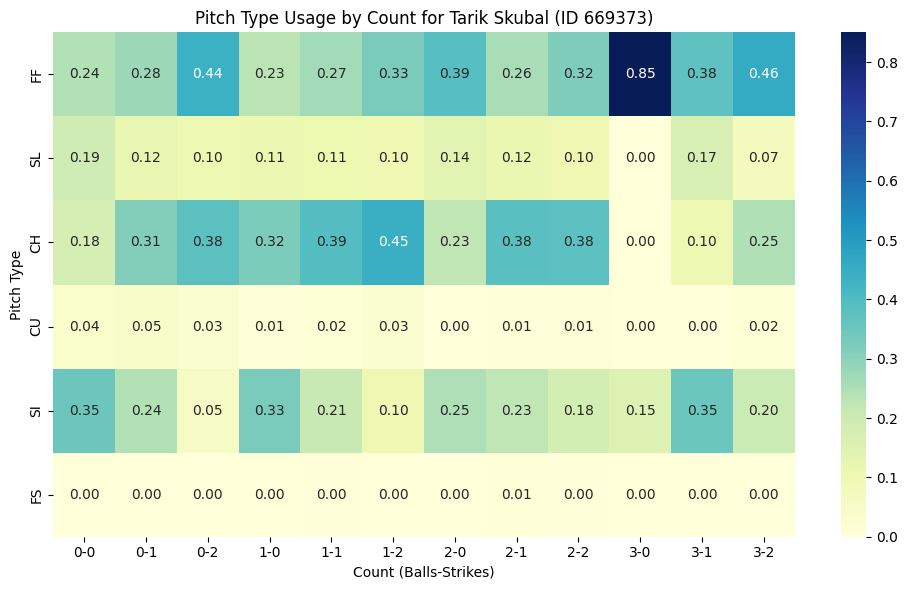

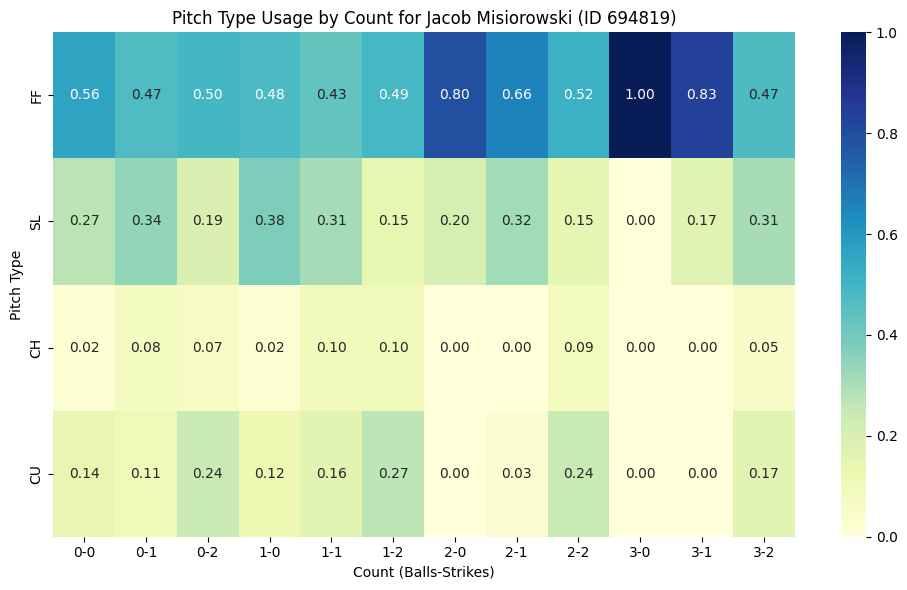

In [39]:
df = data[['pitcher', 'pitch_type', 'balls', 'strikes']].dropna()

# Define consistent pitch type order
pitch_order = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC', 'FS', 'KC', 'KN', 'EP']  # Add/remove as needed

# Step 2: Create count label
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Step 3: Get top 3 pitchers by pitch volume
top_pitchers = df['pitcher'].value_counts().head(3).index.tolist()

# Step 4: Plot heatmap for each pitcher
for pid in pitchers:
    sub_df = df[df['pitcher'] == pid]

    count_matrix = pd.crosstab(sub_df['pitch_type'], sub_df['count'])
    count_matrix = count_matrix.div(count_matrix.sum(axis=0), axis=1)
    count_matrix = count_matrix.reindex(pitch_order).dropna(how='all')

    plt.figure(figsize=(10, 6))
    sns.heatmap(count_matrix, annot=True, fmt=".2f", cmap="YlGnBu")

    # Use name from lookup if available
    name = pitcher_lookup.get(pid, f"Unknown ({pid})")
    plt.title(f'Pitch Type Usage by Count for {name} (ID {pid})')

    plt.xlabel('Count (Balls-Strikes)')
    plt.ylabel('Pitch Type')
    plt.tight_layout()
    plt.show()


### Goal : Predict pitch type based on count, pitcher, and other features.

In [6]:
# Restrict to selected pitch types
pitch_types = ['FF', 'SI', 'SL', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV']
data = data[data['pitch_type'].isin(pitch_types)]

# Create count label
data['count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

# Encode categorical variables
data['pitch_type'] = data['pitch_type'].astype('category')
data['pitcher'] = data['pitcher'].astype('category')
data['count'] = data['count'].astype('category')

# Features and target
X = pd.get_dummies(data[['pitcher', 'count']], drop_first=True)
y = data['pitch_type'].cat.codes

# Drop rare classes (<2 samples)
valid_classes = y.value_counts()[y.value_counts() > 1].index
mask = y.isin(valid_classes)
X, y = X[mask], y[mask]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

labels = sorted(valid_classes)
target_names = [data['pitch_type'].cat.categories[i] for i in labels]

print(classification_report(y_test, y_pred, labels=labels, target_names=target_names))


              precision    recall  f1-score   support

          CH       0.89      0.01      0.02     15389
          CU       0.00      0.00      0.00     10596
          FC       0.81      0.00      0.00     11414
          FF       0.32      1.00      0.49     48090
          FS       0.00      0.00      0.00      5096
          KC       0.00      0.00      0.00      2514
          SI       0.75      0.01      0.03     23297
          SL       0.00      0.00      0.00     22359
          ST       0.00      0.00      0.00     10431
          SV       0.00      0.00      0.00       749

    accuracy                           0.32    149935
   macro avg       0.28      0.10      0.05    149935
weighted avg       0.37      0.32      0.16    149935



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


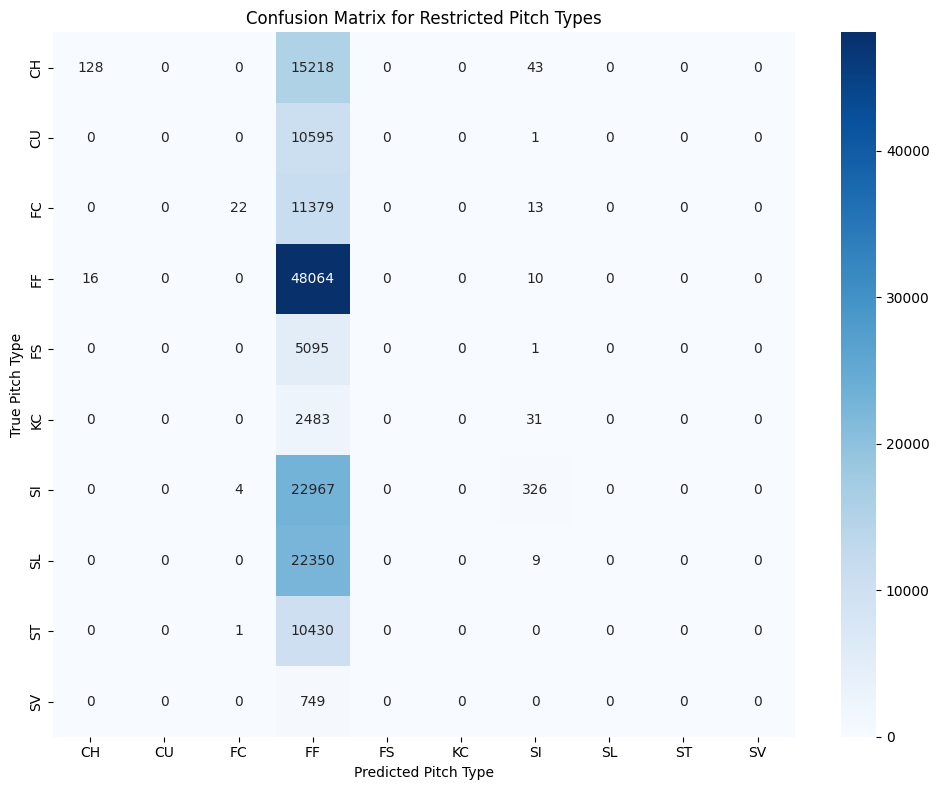

In [8]:
# Confusion Matrix Heatmap

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)

plt.xlabel("Predicted Pitch Type")
plt.ylabel("True Pitch Type")
plt.title("Confusion Matrix for Restricted Pitch Types")
plt.tight_layout()
plt.show()

Goal: Generate synthetic pitch sequences based on learned probabilities.

In [17]:
# Get pitch type probabilities for a pitcher at a count
def simulate_pitch(pitcher_id, count_label):

    input_df = pd.get_dummies(pd.DataFrame({'pitcher': [pitcher_id], 'count': [count_label]}))
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    probs = model.predict_proba(input_df)[0]

    pitch_classes = model.classes_
    pitch_labels = [data['pitch_type'].cat.categories[i] for i in pitch_classes]

    pitch_type = np.random.choice(pitch_labels, p=probs)
    return pitch_type

# Simulate a sequence
sequence = []

for count in ['0-0', '1-0', '1-1', '2-2', '3-2']:
    pitch = simulate_pitch(pitcher_id=pitchers[0], count_label=count)
    sequence.append((count, pitch))

print("Simulated pitch sequence:")

for count, pitch in sequence:
    print(f"Count {count} → Pitch: {pitch}")


Simulated pitch sequence:
Count 0-0 → Pitch: SI
Count 1-0 → Pitch: FF
Count 1-1 → Pitch: FF
Count 2-2 → Pitch: CH
Count 3-2 → Pitch: FF


#### Pitch Simulation :

Synthetic at‑bat or inning sequence instead of just a fixed set of counts.

The idea is to keep sampling pitches until you reach a terminal outcome (strikeout, walk, or ball in play).

In [46]:
# Train with batter + stand included
feature_cols = ['pitcher', 'count', 'batter', 'stand']
X = pd.get_dummies(data[feature_cols], drop_first=True)
y = data['pitch_type'].astype('category').cat.codes

model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
model.fit(X, y)


RandomForestClassifier(max_depth=10, random_state=42)

### Synthetic At-Bat Generator

In [50]:
def simulate_pitch(pitcher_id, count_label, batter_id, stand_label):
    input_df = pd.DataFrame({
        'pitcher': [pitcher_id],
        'count': [count_label],
        'batter': [batter_id],
        'stand': [stand_label]   # e.g. 'R' or 'L'
    })
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    probs = model.predict_proba(input_df)[0]
    pitch_classes = model.classes_
    pitch_labels = [data['pitch_type'].cat.categories[i] for i in pitch_classes]

    return np.random.choice(pitch_labels, p=probs)


def simulate_at_bat(pitcher_id, batter_id, stand_label):
    balls, strikes = 0, 0
    sequence = []

    while True:
        count_label = f"{balls}-{strikes}"
        pitch = simulate_pitch(pitcher_id, count_label, batter_id, stand_label)
        sequence.append((count_label, pitch))

        outcome_roll = np.random.rand()
        if outcome_roll < 0.15:
            return sequence, "Ball in play"
        elif pitch in ["FF", "SL"]:
            strikes += 1
        else:
            balls += 1

        if strikes >= 3:
            return sequence, "Strikeout"
        if balls >= 4:
            return sequence, "Walk"

batters = [123456, 234567, 345678]   # example batter IDs
stands = ['R', 'L', 'R']             # handedness for each batter

seq, outcome = simulate_at_bat(pitcher_id=pitchers[0], batter_id=batters[0], stand_label=stands[0])


# Example: simulate one at-bat
seq, outcome = simulate_at_bat(pitcher_id=pitchers[0], batter_id=batters[0], stand_label='R')
print("Simulated at-bat sequence:")
for count, pitch in seq:
    print(f"Count {count} → Pitch: {pitch}")
print("Outcome:", outcome)


Simulated at-bat sequence:
Count 0-0 → Pitch: FF
Count 0-1 → Pitch: SL
Outcome: Ball in play


### Synthetic Inning Generator

In [57]:

# Retrain the model with clean features


# --- Training setup ---
# Use only pitcher + count as features
X = pd.get_dummies(data[['pitcher', 'count']], drop_first=True)
y = data['pitch_type'].astype('category').cat.codes

# Train model
model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
model.fit(X, y)

# Save feature names for prediction alignment
feature_names = list(X.columns)
pitch_categories = data['pitch_type'].astype('category').cat.categories

# Pitch simulation

def simulate_pitch(pitcher_id, count_label):
    # Build input row with only training features
    input_df = pd.DataFrame({'pitcher': [pitcher_id], 'count': [count_label]})
    input_df = pd.get_dummies(input_df)

    # Align with training feature names and order
    input_df = input_df.reindex(columns=feature_names, fill_value=0)

    # Predict probabilities
    probs = model.predict_proba(input_df)[0]
    pitch_classes = model.classes_
    pitch_labels = [pitch_categories[i] for i in pitch_classes]

    return np.random.choice(pitch_labels, p=probs)

# At‑bat simulation

def simulate_at_bat(pitcher_id):
    balls, strikes = 0, 0
    sequence = []

    while True:
        count_label = f"{balls}-{strikes}"
        pitch = simulate_pitch(pitcher_id, count_label)
        sequence.append((count_label, pitch))

        outcome_roll = np.random.rand()

        if outcome_roll < 0.15:  # 15% chance ball in play
            return sequence, "Ball in play"
        elif pitch in ["FF", "SL"]:  # treat fastballs/sliders as more likely strikes
            strikes += 1
        else:
            balls += 1

        if strikes >= 3:
            return sequence, "Strikeout"
        if balls >= 4:
            return sequence, "Walk"

# Inning simulation

def simulate_inning(pitcher_id, max_batters=9):
    outs, runs = 0, 0
    bases = [False, False, False]  # 1B, 2B, 3B
    log = []

    batter_num = 1
    while outs < 3 and batter_num <= max_batters:
        seq, outcome = simulate_at_bat(pitcher_id)

        if outcome == "Strikeout":
            outs += 1
            log.append((batter_num, outcome, seq))

        elif outcome == "Walk":
            if bases[0]:
                if bases[1]:
                    if bases[2]:
                        runs += 1
                    bases[2] = True
                bases[1] = True
            bases[0] = True
            log.append((batter_num, outcome, seq))

        elif outcome == "Ball in play":
            if np.random.rand() < 0.5:
                outs += 1
                log.append((batter_num, "Out on play", seq))
            else:
                runs_scored = sum(bases)
                runs += runs_scored
                bases = [True, False, False]
                log.append((batter_num, f"Hit ({runs_scored} runs)", seq))

        batter_num += 1

    return log, runs, outs

# Run a test inning

inning_log, runs, outs = simulate_inning(pitcher_id=pitchers[0])
print("Simulated inning:")
for batter, outcome, seq in inning_log:
    print(f"Batter {batter}: {outcome}")
print(f"Runs scored: {runs}, Outs: {outs}")



Simulated inning:
Batter 1: Out on play
Batter 2: Hit (0 runs)
Batter 3: Strikeout
Batter 4: Out on play
Runs scored: 0, Outs: 3


#### Full 9‑inning game simulator

In [58]:
def simulate_game(pitcher_A, pitcher_B, innings=9):
    score_A, score_B = 0, 0
    inning_scores_A, inning_scores_B = [], []
    game_log = []

    for inning in range(1, innings+1):
        # Top of inning: Team A bats vs Team B pitcher
        log_top, runs_top, outs_top = simulate_inning(pitcher_B)
        score_A += runs_top
        inning_scores_A.append(runs_top)
        game_log.append((f"Top {inning}", log_top, runs_top))

        # Bottom of inning: Team B bats vs Team A pitcher
        log_bot, runs_bot, outs_bot = simulate_inning(pitcher_A)
        score_B += runs_bot
        inning_scores_B.append(runs_bot)
        game_log.append((f"Bottom {inning}", log_bot, runs_bot))

    return {
        "score_A": score_A,
        "score_B": score_B,
        "inning_scores_A": inning_scores_A,
        "inning_scores_B": inning_scores_B,
        "game_log": game_log
    }


# --- Example: simulate one full game ---
game_result = simulate_game(pitcher_A=pitchers[0], pitcher_B=pitchers[1])

print("Final Score:")
print(f"Team A: {game_result['score_A']} runs")
print(f"Team B: {game_result['score_B']} runs")

print("\nInning by inning:")
for i in range(len(game_result['inning_scores_A'])):
    print(f"Inning {i+1}: Team A {game_result['inning_scores_A'][i]}, Team B {game_result['inning_scores_B'][i]}")


Final Score:
Team A: 9 runs
Team B: 6 runs

Inning by inning:
Inning 1: Team A 0, Team B 0
Inning 2: Team A 5, Team B 0
Inning 3: Team A 0, Team B 0
Inning 4: Team A 0, Team B 0
Inning 5: Team A 0, Team B 0
Inning 6: Team A 0, Team B 5
Inning 7: Team A 2, Team B 0
Inning 8: Team A 1, Team B 1
Inning 9: Team A 1, Team B 0


#### Game Simulator

In [59]:
def simulate_game(pitcher_A, pitcher_B, innings=9):
    score_A, score_B = 0, 0
    inning_scores_A, inning_scores_B = [], []
    game_log = []

    for inning in range(1, innings+1):
        # Top of inning: Team A bats vs Team B pitcher
        log_top, runs_top, outs_top = simulate_inning(pitcher_B)
        score_A += runs_top
        inning_scores_A.append(runs_top)
        game_log.append((f"Top {inning}", log_top, runs_top))

        # Bottom of inning: Team B bats vs Team A pitcher
        log_bot, runs_bot, outs_bot = simulate_inning(pitcher_A)
        score_B += runs_bot
        inning_scores_B.append(runs_bot)
        game_log.append((f"Bottom {inning}", log_bot, runs_bot))

    return {
        "score_A": score_A,
        "score_B": score_B,
        "inning_scores_A": inning_scores_A,
        "inning_scores_B": inning_scores_B,
        "game_log": game_log
    }


def print_box_score(game_result):
    innings = len(game_result['inning_scores_A'])
    print("\nBox Score")
    print("Inning | " + " ".join([str(i+1) for i in range(innings)]) + " | R")
    print("-------+" + "---"*innings + "+--")
    print("Team A | " + " ".join([str(r) for r in game_result['inning_scores_A']]) + f" | {game_result['score_A']}")
    print("Team B | " + " ".join([str(r) for r in game_result['inning_scores_B']]) + f" | {game_result['score_B']}")


#### Example Run

In [60]:
# Simulate a full game
game_result = simulate_game(pitcher_A=pitchers[0], pitcher_B=pitchers[1])

# Print final score
print("Final Score:")
print(f"Team A: {game_result['score_A']} runs")
print(f"Team B: {game_result['score_B']} runs")

# Print box score
print_box_score(game_result)


Final Score:
Team A: 6 runs
Team B: 7 runs

Box Score
Inning | 1 2 3 4 5 6 7 8 9 | R
-------+---------------------------+--
Team A | 0 0 2 4 0 0 0 0 0 | 6
Team B | 0 0 4 1 1 0 0 0 1 | 7


#### Pitch type probability simulator

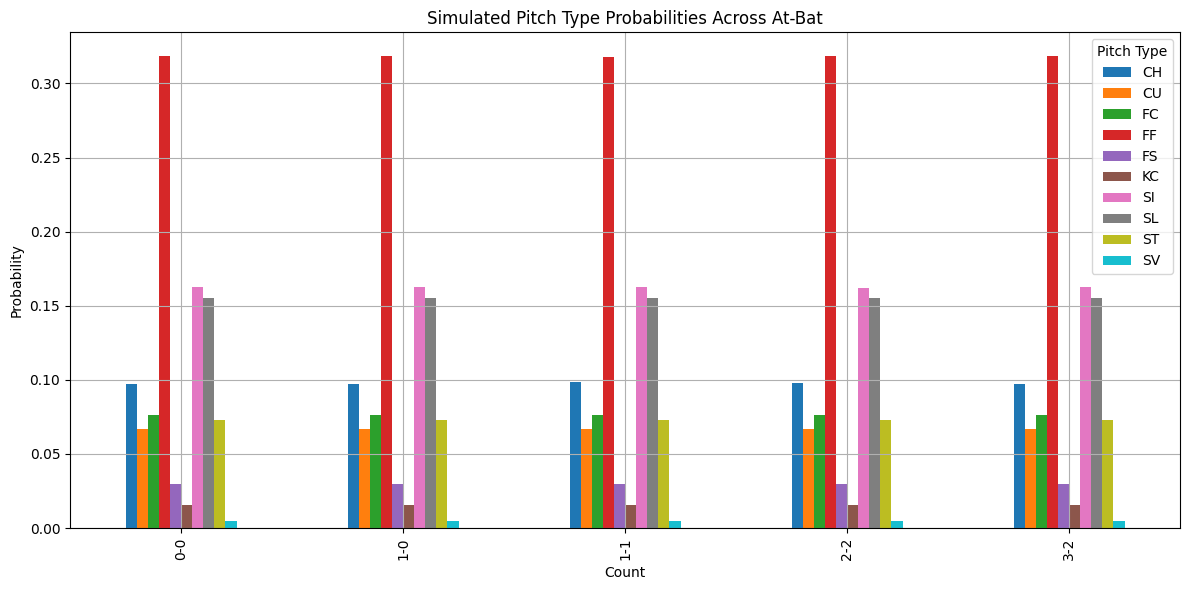

In [65]:
# Create a “count” feature

data['count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

# Build training features & labels

feature_cols = ['pitcher', 'batter', 'stand', 'count']

X = pd.get_dummies(data[feature_cols], drop_first=True)
y = data['pitch_type'].astype('category').cat.codes

# Train model
model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
model.fit(X, y)

# Save feature names and pitch categories
feature_names = list(X.columns)
pitch_labels = data['pitch_type'].astype('category').cat.categories

# Choose a pitcher, batter, and stance
pitcher_id = data['pitcher'].value_counts().index[0]
batter_id = data['batter'].value_counts().index[0]

stand = 'R' # right-handed batter

# Simulate probabilities across counts
counts = ['0-0', '1-0', '1-1', '2-2', '3-2']

# Get the actual classes the model knows
pitch_classes = model.classes_
pitch_labels = [data['pitch_type'].cat.categories[i] for i in pitch_classes]

# Build probability matrix
prob_matrix = []

for count in counts:
    input_df = pd.DataFrame({
        'pitcher': [pitcher_id],
        'batter': [batter_id],
        'stand': [stand],
        'count': [count]
    })

    # Dummy encode
    input_df = pd.get_dummies(input_df)

    # Align with training columns
    input_df = input_df.reindex(columns=feature_names, fill_value=0)

    # Predict
    probs = model.predict_proba(input_df)[0]
    prob_matrix.append(probs)

# Convert to DataFrame for plotting
prob_df = pd.DataFrame(prob_matrix, columns=pitch_labels, index=counts)

# Plot grouped bar chart
prob_df.plot(kind='bar', figsize=(12, 6))
plt.title('Simulated Pitch Type Probabilities Across At-Bat')
plt.xlabel('Count')
plt.ylabel('Probability')
plt.legend(title='Pitch Type')
plt.grid(True)
plt.tight_layout()
plt.show()


Goal: Add batter handedness or ID to improve predictions.

Updated model with batter context (ordinal encoding):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          CH       0.39      0.00      0.00     15389
          CS       0.00      0.00      0.00        73
          CU       0.63      0.00      0.01     10596
          EP       0.00      0.00      0.00       198
          FA       0.00      0.00      0.00       180
          FC       0.63      0.00      0.00     11414
          FF       0.33      0.99      0.49     48090
          FO       0.00      0.00      0.00       108
          FS       0.55      0.01      0.02      5096
          KC       0.00      0.00      0.00      2515
          KN       0.00      0.00      0.00        28
          PO       0.00      0.00      0.00        11
          SC       0.00      0.00      0.00         1
          SI       0.47      0.07      0.12     23297
          SL       0.51      0.01      0.03     22359
          ST       1.00      0.00      0.00     10431
          SV       0.00      0.00      0.00       749

    accuracy              

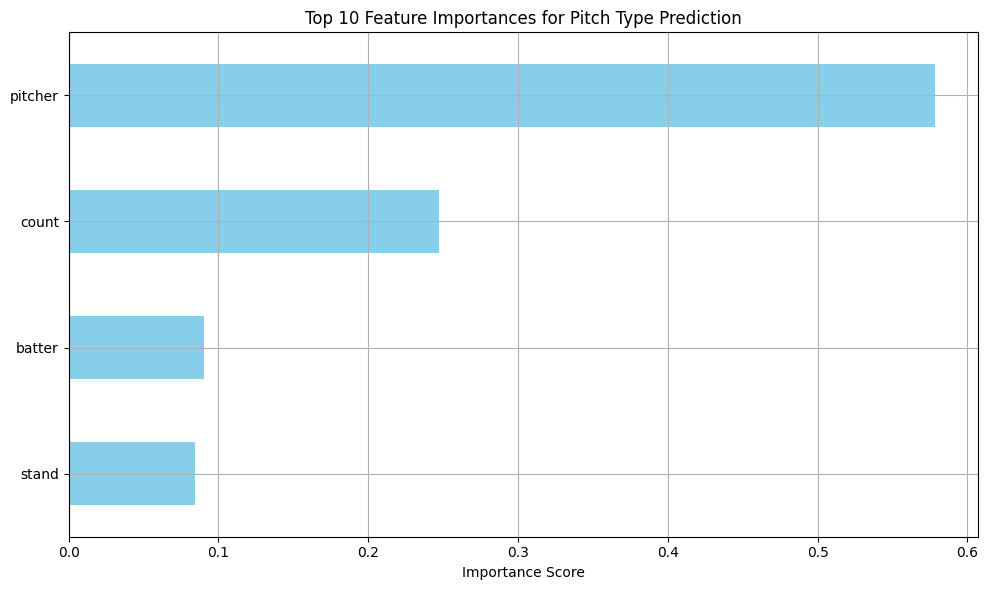

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report

# --- Step 1: Build dataset ---
df = data[['pitch_type', 'pitcher', 'batter', 'stand', 'balls', 'strikes']].dropna()
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# --- Step 2: Encode categorical variables ---
df['pitch_type'] = df['pitch_type'].astype('category')

# Filter out rare pitch types (<2 samples)
counts = df['pitch_type'].value_counts()
valid_types = counts[counts >= 2].index
df = df[df['pitch_type'].isin(valid_types)]

# --- Step 3: Features and labels ---
X_raw = df[['pitcher', 'batter', 'stand', 'count']]
y = df['pitch_type'].cat.codes

# Ordinal encoding (compact representation)
encoder = OrdinalEncoder()
X = encoder.fit_transform(X_raw)

# --- Step 4: Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.2
)

# --- Step 5: Train model ---
model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
model.fit(X_train, y_train)

# --- Step 6: Evaluate ---
print("Updated model with batter context (ordinal encoding):")

# Get the actual classes present in y
present_classes = np.unique(y)

# Map those codes back to their category names
target_names = df['pitch_type'].cat.categories[present_classes]

print(classification_report(
    y_test,
    model.predict(X_test),
    labels=present_classes,
    target_names=target_names
))


# --- Step 7: Feature importance ---
importances = pd.Series(model.feature_importances_, index=X_raw.columns)
top_features = importances.sort_values(ascending=False).head(10)

# --- Step 8: Plot feature importance ---
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='skyblue')
plt.title('Top 10 Feature Importances for Pitch Type Prediction')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


2. Kernel Density Estimation (KDE) :

  - Use case:
    - Smooth approximation of continuous distributions (e.g., pitch speed, spin rate).

  - Fitting:
    - Fit KDE to observed data using bandwidth selection (Silverman’s rule or cross-validation).

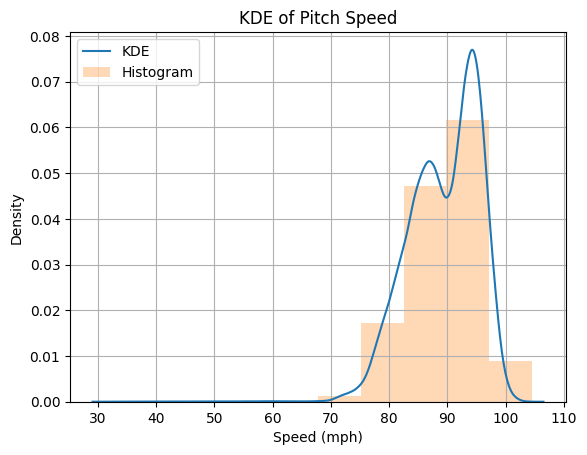

In [6]:

# Example: pitch speeds
pitch_speeds = data['release_speed'].dropna()

# Fit KDE using Silverman's rule
kde = gaussian_kde(pitch_speeds, bw_method='silverman')

# Evaluate density
x_vals = np.linspace(min(pitch_speeds) - 2, max(pitch_speeds) + 2, 500)
y_vals = kde(x_vals)

# Plot
plt.plot(x_vals, y_vals, label='KDE')
plt.hist(pitch_speeds, bins=10, density=True, alpha=0.3, label='Histogram')
plt.title('KDE of Pitch Speed')
plt.xlabel('Speed (mph)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


### Sample synthetic pitch speeds from KDE

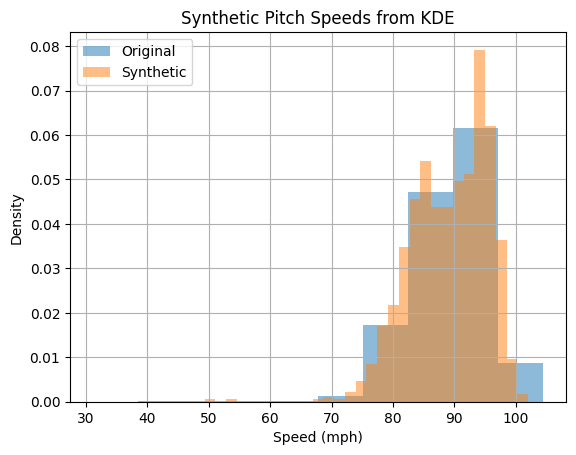

In [7]:

synthetic_speeds = kde.resample(1000)[0]

# Plot synthetic vs original
plt.hist(pitch_speeds, bins=10, alpha=0.5, label='Original', density=True)
plt.hist(synthetic_speeds, bins=30, alpha=0.5, label='Synthetic', density=True)
plt.title('Synthetic Pitch Speeds from KDE')
plt.xlabel('Speed (mph)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


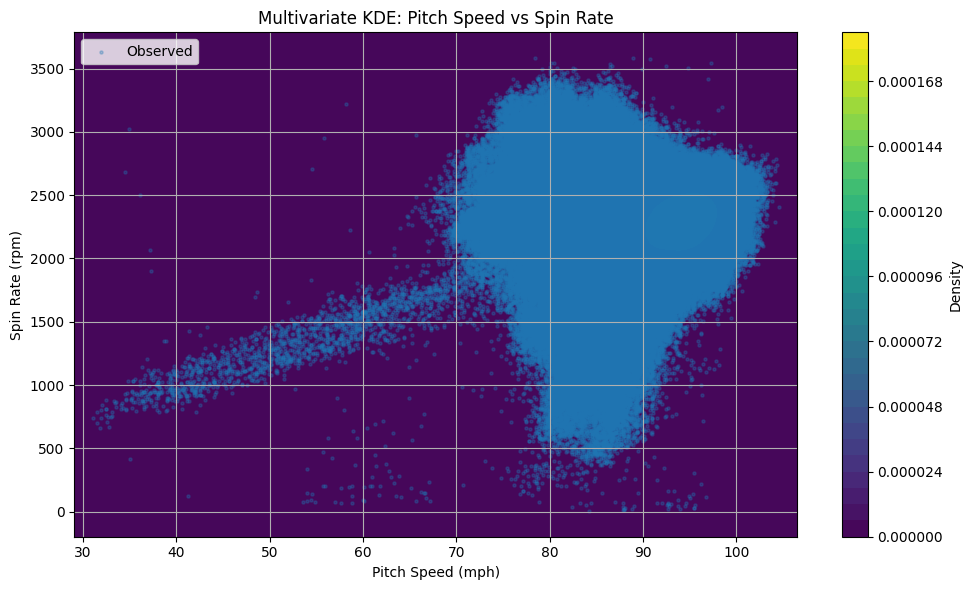

In [8]:
# Step 1: Load and clean Statcast data
df = data
df = df[['release_speed', 'release_spin_rate']].dropna()
df = df.astype({'release_speed': 'float64', 'release_spin_rate': 'float64'})  # Force numeric

# Step 2: Extract data for KDE
data = df[['release_speed', 'release_spin_rate']].to_numpy().T  # shape (2, N)

# Step 3: Fit KDE
kde = gaussian_kde(data, bw_method='silverman')

# Step 4: Create grid for evaluation
x = np.linspace(data[0].min() - 2, data[0].max() + 2, 100)
y = np.linspace(data[1].min() - 200, data[1].max() + 200, 100)
X, Y = np.meshgrid(x, y)
positions = np.vstack([X.ravel(), Y.ravel()]).astype('float64')  # Ensure numeric

# Step 5: Evaluate KDE
Z = kde(positions).reshape(X.shape)

# Step 6: Plot contour
plt.figure(figsize=(10, 6))
plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(label='Density')
plt.scatter(data[0], data[1], s=5, alpha=0.3, label='Observed')
plt.title('Multivariate KDE: Pitch Speed vs Spin Rate')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Spin Rate (rpm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


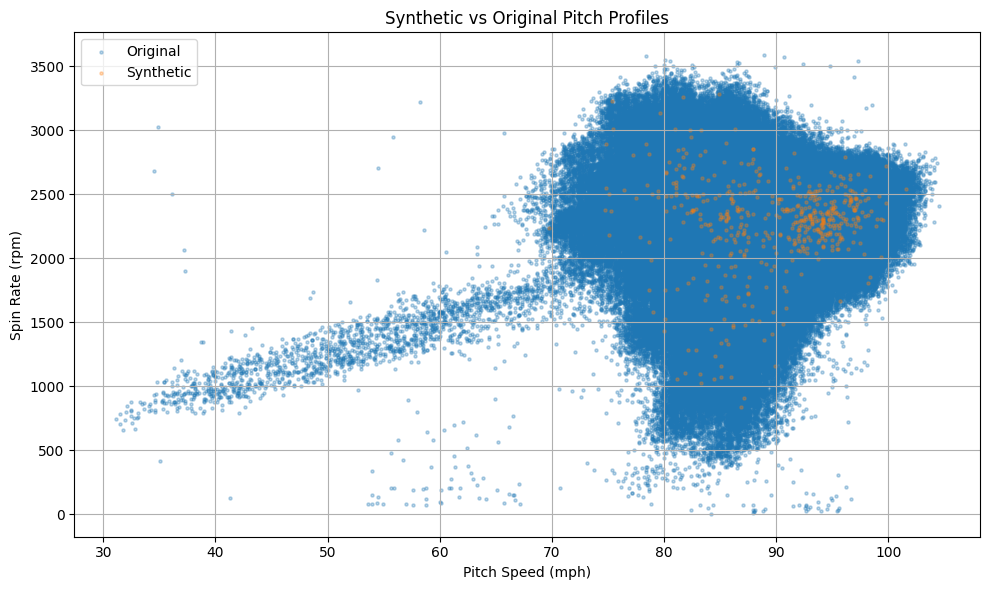

In [9]:
# Step 6: Sample synthetic pitch profiles
samples = kde.resample(500).T
synthetic_df = pd.DataFrame(samples, columns=['release_speed', 'release_spin_rate'])

# Optional: Plot synthetic vs original
plt.figure(figsize=(10, 6))
plt.scatter(df['release_speed'], df['release_spin_rate'], alpha=0.3, label='Original', s=5)
plt.scatter(synthetic_df['release_speed'], synthetic_df['release_spin_rate'], alpha=0.3, label='Synthetic', s=5)
plt.title('Synthetic vs Original Pitch Profiles')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Spin Rate (rpm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Apply Clustering (e.g., KMeans)

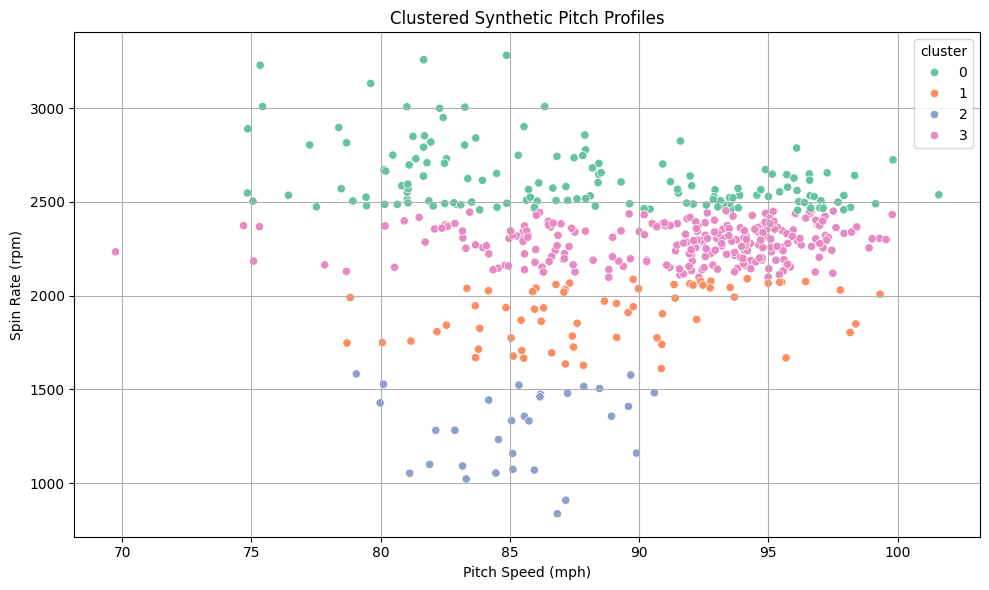

In [10]:
# Choose number of clusters (e.g., 4 for FF, SL, CH, CU)

kmeans = KMeans(n_clusters=4, random_state=42)
synthetic_df['cluster'] = kmeans.fit_predict(synthetic_df[['release_speed', 'release_spin_rate']])

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=synthetic_df, x='release_speed', y='release_spin_rate', hue='cluster', palette='Set2')
plt.title('Clustered Synthetic Pitch Profiles')
plt.xlabel('Pitch Speed (mph)')
plt.ylabel('Spin Rate (rpm)')
plt.grid(True)
plt.tight_layout()
plt.show()

4. Markov Transition Models :

  - Use case:
    - Generative modeling of sequences (e.g., pitch types, batter outcomes).

  - Fitting:
    - Estimate transition probabilities between states (e.g., pitch type → result → next pitch).

In [17]:
# Step 1: Define states
states = ['0-0', '0-1', '0-2', '1-0', '1-1', '1-2', '2-0', '2-1', '2-2', '3-0', '3-1', '3-2', 'K', 'BB', 'H']

# Step 2: Define transition matrix (simplified example)
transition_matrix = {
    '0-0': {'1-0': 0.3, '0-1': 0.5, 'H': 0.2},
    '1-0': {'2-0': 0.4, '1-1': 0.4, 'H': 0.2},
    '0-1': {'0-2': 0.5, '1-1': 0.3, 'H': 0.2},
    '1-1': {'2-1': 0.3, '1-2': 0.4, 'H': 0.3},
    '2-0': {'3-0': 0.5, '2-1': 0.3, 'H': 0.2},
    '0-2': {'K': 0.6, '1-2': 0.3, 'H': 0.1},
    '1-2': {'K': 0.5, '2-2': 0.3, 'H': 0.2},
    '2-1': {'3-1': 0.4, '2-2': 0.4, 'H': 0.2},
    '2-2': {'K': 0.4, 'BB': 0.3, 'H': 0.3},
    '3-0': {'BB': 0.6, '3-1': 0.3, 'H': 0.1},
    '3-1': {'BB': 0.5, '3-2': 0.3, 'H': 0.2},
    '3-2': {'K': 0.3, 'BB': 0.3, 'H': 0.4}
}

# Step 3: Simulate sequence
def simulate_sequence(start='0-0'):
    sequence = [start]
    current = start
    while current not in ['K', 'BB', 'H']:
        next_states = list(transition_matrix[current].keys())
        probs = list(transition_matrix[current].values())
        current = random.choices(next_states, probs)[0]
        sequence.append(current)
    return sequence

# Example
for _ in range(5):
    print(simulate_sequence())


['0-0', '1-0', '2-0', '3-0', 'BB']
['0-0', 'H']
['0-0', 'H']
['0-0', '0-1', 'H']
['0-0', 'H']


In [49]:
data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
43,FS,2025-11-01,92.1,-2.02,5.15,"Yamamoto, Yoshinobu",672386,808967,grounded_into_double_play,hit_into_play,...,<NA>,2.33,0.48,0.48,36.9,8.375233,-7.664043,17.979522,48.911447,37.014581
48,CU,2025-11-01,80.3,-1.7,5.45,"Yamamoto, Yoshinobu",672386,808967,NaN,called_strike,...,<NA>,4.85,-1.36,-1.36,48.1,<NA>,<NA>,<NA>,<NA>,<NA>
51,FC,2025-11-01,92.8,-1.91,5.24,"Yamamoto, Yoshinobu",672386,808967,NaN,foul,...,<NA>,2.04,-0.23,-0.23,39.1,14.162806,5.694338,22.383742,47.652657,23.055298
53,FS,2025-11-01,90.9,-1.97,5.26,"Yamamoto, Yoshinobu",680718,808967,walk,blocked_ball,...,<NA>,2.74,0.69,-0.69,40.1,<NA>,<NA>,<NA>,<NA>,<NA>
57,FS,2025-11-01,90.8,-2.02,5.27,"Yamamoto, Yoshinobu",680718,808967,NaN,ball,...,<NA>,2.3,0.23,-0.23,38.0,<NA>,<NA>,<NA>,<NA>,<NA>


KeyError: 'batter_name'

In [31]:

# Step 1: Load pitch-by-pitch data into a DataFrame
cols = ['game_pk', 'at_bat_number', 'pitch_number', 'balls', 'strikes', 'events', 'description']
df = pd.DataFrame(data, columns=cols)   # <-- FIX: convert array to DataFrame with named columns

# Step 2: Filter out terminal counts
df = df[(df['balls'] <= 3) & (df['strikes'] <= 2)]

# Step 3: Create count label
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Step 4: Create plate appearance ID and sort
df['pa_id'] = df['game_pk'].astype(str) + '-' + df['at_bat_number'].astype(str)
df = df.sort_values(['pa_id', 'pitch_number'])

# Step 5: Define terminal outcomes
def classify_terminal(row):
    if row['events'] in ['strikeout', 'strikeout_double_play']:
        return 'K'
    elif row['events'] in ['walk', 'intent_walk']:
        return 'BB'
    elif row['events'] in ['single', 'double', 'triple', 'home_run']:
        return 'H'
    elif row['events'] in ['field_out', 'force_out', 'double_play', 'grounded_into_double_play']:
        return 'Out'
    return None

df['outcome'] = df.apply(classify_terminal, axis=1)

# Step 6: Compute next count or terminal outcome
df['next_state'] = df.groupby('pa_id')['count'].shift(-1)
df['next_outcome'] = df.groupby('pa_id')['outcome'].shift(-1)

# Step 7: Combine next count and outcome
df['next'] = df['next_state']
mask = df['next_outcome'].notna()
df.loc[mask, 'next'] = df.loc[mask, 'next_outcome'].values

# Step 8: Drop last pitch of each PA (no next state)
df['is_last'] = df.groupby('pa_id')['pitch_number'].transform('max') == df['pitch_number']
df = df[~df['is_last']]

# Step 9: Filter valid transitions
valid_counts = ['0-0','0-1','0-2','1-0','1-1','1-2','2-0','2-1','2-2','3-0','3-1','3-2']
valid_next = valid_counts + ['K', 'BB', 'H', 'Out']
df = df[df['count'].isin(valid_counts) & df['next'].isin(valid_next)]

# Step 10: Build transition matrix
transitions = df.groupby(['count', 'next']).size().unstack(fill_value=0)
transition_matrix = transitions.div(transitions.sum(axis=1), axis=0)

# Reindex to standard count order
index = ['0-0','0-1','0-2','1-0','1-1','1-2','2-0','2-1','2-2','3-0','3-1','3-2']
df_matrix = pd.DataFrame(transition_matrix, index=index)

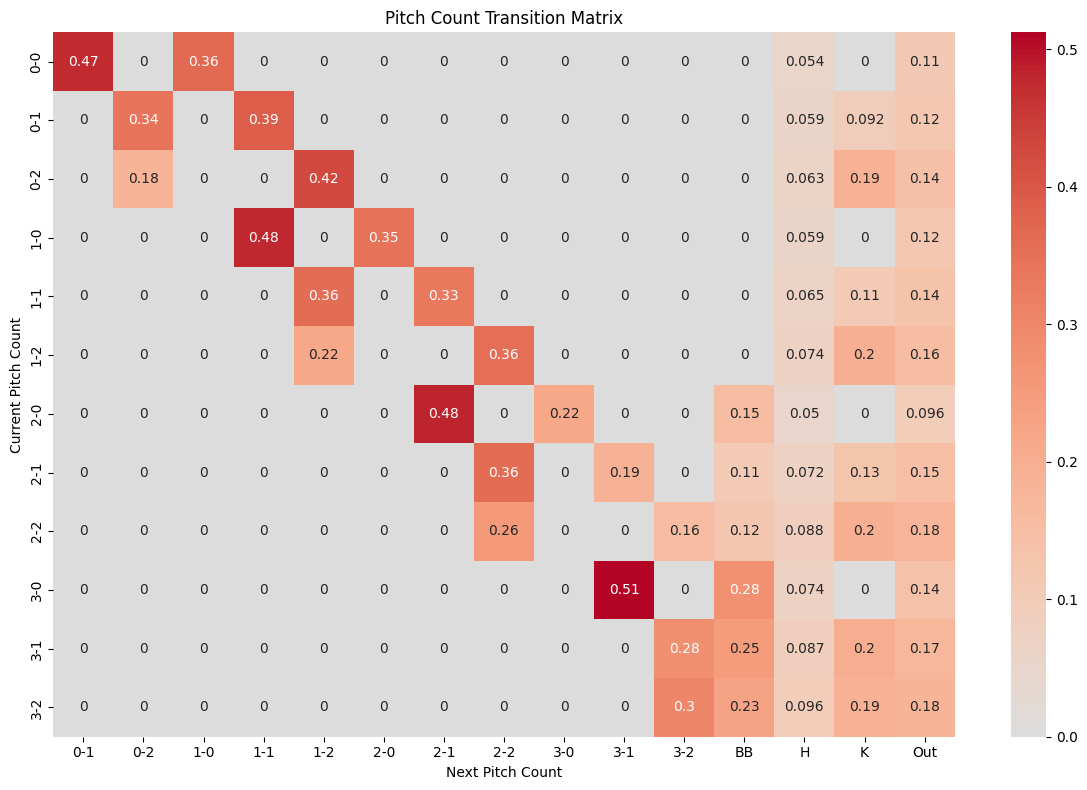

In [48]:


# Step 12: Visualize the difference with names
plt.figure(figsize=(12, 8))
sns.heatmap(transition_matrix, annot=True, cmap='coolwarm', center=0)
plt.title(f"Pitch Count Transition Matrix")
plt.xlabel("Next Pitch Count")
plt.ylabel("Current Pitch Count")
plt.tight_layout()
plt.show()

/tmp/ipython-input-837371022.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


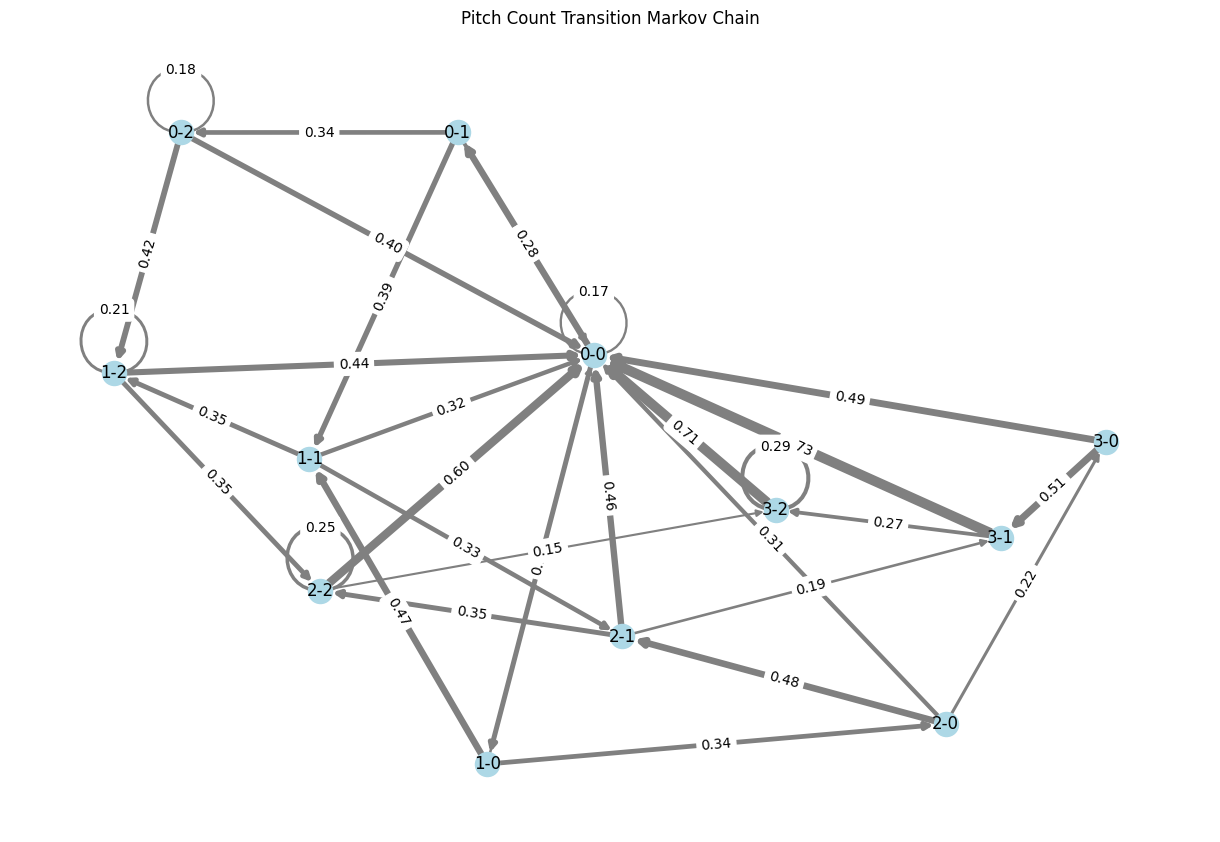

In [33]:

# Step 1: Load pitch-by-pitch data
df = df[['balls', 'strikes']].dropna()
df = df[(df['balls'] <= 3) & (df['strikes'] <= 2)]  # exclude terminal counts

# Step 2: Create count state labels
df['count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)
df['next_count'] = df['count'].shift(-1)

# Step 3: Filter valid transitions
df = df[df['next_count'].notna()]
valid_counts = df['count'].isin([
    '0-0','0-1','0-2','1-0','1-1','1-2','2-0','2-1','2-2','3-0','3-1','3-2'
])
df = df[valid_counts]

# Step 4: Build transition matrix
transitions = df.groupby(['count', 'next_count']).size().unstack(fill_value=0)
transition_probs = transitions.div(transitions.sum(axis=1), axis=0)

# Step 5: Simulate sequences
def simulate_sequence(matrix, start='0-0', max_steps=10):
    sequence = [start]
    current = start
    for _ in range(max_steps):
        if current not in matrix.index:
            break
        next_states = matrix.columns
        probs = matrix.loc[current].values
        if probs.sum() == 0:
            break
        current = np.random.choice(next_states, p=probs)
        sequence.append(current)
    return sequence

sequences = [simulate_sequence(transition_probs) for _ in range(1000)]

# Step 6: Visualize as directed graph
G = nx.DiGraph()
for from_state in transition_probs.index:
    for to_state in transition_probs.columns:
        prob = transition_probs.loc[from_state, to_state]
        if prob > 0:
            G.add_edge(from_state, to_state, weight=prob)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
edges = G.edges(data=True)
weights = [d['weight'] * 10 for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', width=weights, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{d['weight']:.2f}" for u, v, d in edges})
plt.title("Pitch Count Transition Markov Chain")
plt.tight_layout()
plt.show()

Pitch Count Sequence Simulation Code

In [34]:

transition_dict = transition_matrix.dropna(how='all').to_dict(orient='index')

# Step 2: Convert to nested dictionary
transition_dict = transition_matrix.to_dict(orient='index')

# Step 3: Simulate pitch count sequence
def simulate_sequence(start='0-0'):
    sequence = [start]
    current = start
    terminal_states = ['K', 'BB', 'H', 'Out']
    while current not in terminal_states:
        if current not in transition_dict:
            break  # safety check
        next_states = list(transition_dict[current].keys())
        probs = list(transition_dict[current].values())
        current = random.choices(next_states, weights=probs, k=1)[0]
        sequence.append(current)
    return sequence

# Step 4: Run multiple simulations
for i in range(5):
    seq = simulate_sequence()
    print(f"Plate Appearance {i+1}: {' → '.join(seq)}")

Plate Appearance 1: 0-0 → 0-1 → 1-1 → Out
Plate Appearance 2: 0-0 → 0-1 → 1-1 → 2-1 → 2-2 → 2-2 → H
Plate Appearance 3: 0-0 → 0-1 → 1-1 → 2-1 → H
Plate Appearance 4: 0-0 → 0-1 → 0-2 → 1-2 → K
Plate Appearance 5: 0-0 → 0-1 → 1-1 → 1-2 → K


Outcome Frequencies (1000 Simulated Plate Appearances):
BB     0.106
H      0.212
K      0.264
Out    0.418
Name: proportion, dtype: float64

 Pitch Count Stats per Plate Appearance:
count    1000.00
mean        4.47
std         1.80
min         2.00
25%         3.00
50%         4.00
75%         6.00
max        12.00
dtype: float64


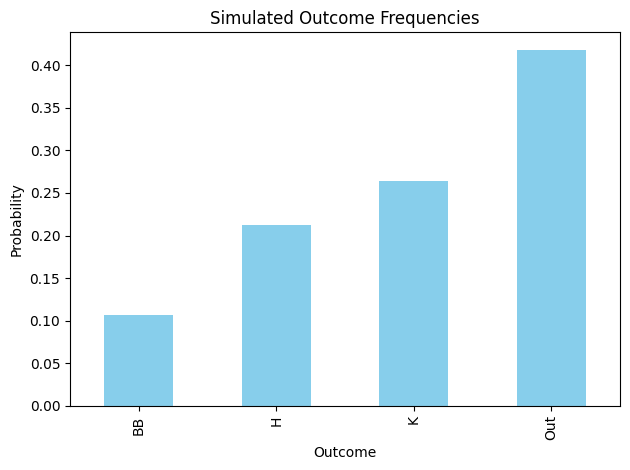

In [36]:
# Step 3: Simulate many plate appearances
def simulate_many(n=1000):
    outcomes = []
    pitch_counts = []
    for _ in range(n):
        seq = simulate_sequence()
        outcomes.append(seq[-1])
        pitch_counts.append(len(seq))
    return outcomes, pitch_counts

# Step 4: Run simulation
n_simulations = 1000
outcomes, pitch_counts = simulate_many(n_simulations)

# Step 5: Summarize results
outcome_freq = pd.Series(outcomes).value_counts(normalize=True).sort_index()
pitch_stats = pd.Series(pitch_counts).describe()

print("Outcome Frequencies (1000 Simulated Plate Appearances):")
print(outcome_freq.round(3))
print("\n Pitch Count Stats per Plate Appearance:")
print(pitch_stats.round(2))

# Step 6: Optional visualization
outcome_freq.plot(kind='bar', color='skyblue', title='Simulated Outcome Frequencies')
plt.ylabel('Probability')
plt.xlabel('Outcome')
plt.tight_layout()
plt.show()

Full Inning Simulation Code

In [38]:
terminal_states = ['K', 'BB', 'H', 'Out']

# Simulate a single plate appearance
def simulate_sequence(start='0-0'):
    sequence = [start]
    current = start
    while current not in terminal_states:
        if current not in transition_dict:
            break
        next_states = list(transition_dict[current].keys())
        probs = list(transition_dict[current].values())
        current = random.choices(next_states, weights=probs, k=1)[0]
        sequence.append(current)
    return current, len(sequence)

# Simulate one half-inning
def simulate_half_inning():
    outs = 0
    runs = 0
    bases = [False, False, False]  # [1st, 2nd, 3rd]
    pitch_total = 0

    def advance_runners(outcome):
        nonlocal runs, bases
        if outcome == 'H':
            if bases[2]: runs += 1
            if bases[1]: bases[2] = True
            if bases[0]: bases[1] = True
            bases[0] = True
        elif outcome == 'BB':
            if bases[0] and bases[1] and bases[2]: runs += 1
            elif bases[0] and bases[1]: bases[2] = True
            elif bases[0]: bases[1] = True
            bases[0] = True

    while outs < 3:
        outcome, pitch_count = simulate_sequence()
        pitch_total += pitch_count
        if outcome in ['Out', 'K']:
            outs += 1
        else:
            advance_runners(outcome)

    return runs, pitch_total

# Simulate full 9-inning game
def simulate_game():
    home_runs = 0
    away_runs = 0
    home_pitches = 0
    away_pitches = 0

    print("Simulating 9-Inning Game")
    for inning in range(1, 10):
        away_r, away_p = simulate_half_inning()
        home_r, home_p = simulate_half_inning()
        away_runs += away_r
        home_runs += home_r
        away_pitches += away_p
        home_pitches += home_p
        print(f"Inning {inning}: Away {away_r} runs ({away_p} pitches), Home {home_r} runs ({home_p} pitches)")

    print(f"\n Final Score: Away {away_runs} – Home {home_runs}")
    print(f"Total Pitches: Away {away_pitches}, Home {home_pitches}")

simulate_game()

Simulating 9-Inning Game
Inning 1: Away 0 runs (15 pitches), Home 0 runs (29 pitches)
Inning 2: Away 0 runs (19 pitches), Home 0 runs (14 pitches)
Inning 3: Away 0 runs (20 pitches), Home 0 runs (19 pitches)
Inning 4: Away 0 runs (14 pitches), Home 0 runs (18 pitches)
Inning 5: Away 0 runs (18 pitches), Home 0 runs (25 pitches)
Inning 6: Away 0 runs (20 pitches), Home 0 runs (12 pitches)
Inning 7: Away 0 runs (28 pitches), Home 0 runs (13 pitches)
Inning 8: Away 0 runs (21 pitches), Home 1 runs (23 pitches)
Inning 9: Away 0 runs (26 pitches), Home 0 runs (12 pitches)

 Final Score: Away 0 – Home 1
Total Pitches: Away 181, Home 165


Batter Vs Pitcher

Top matchup: Blake Snell vs Davis Schneider with 35 pitches


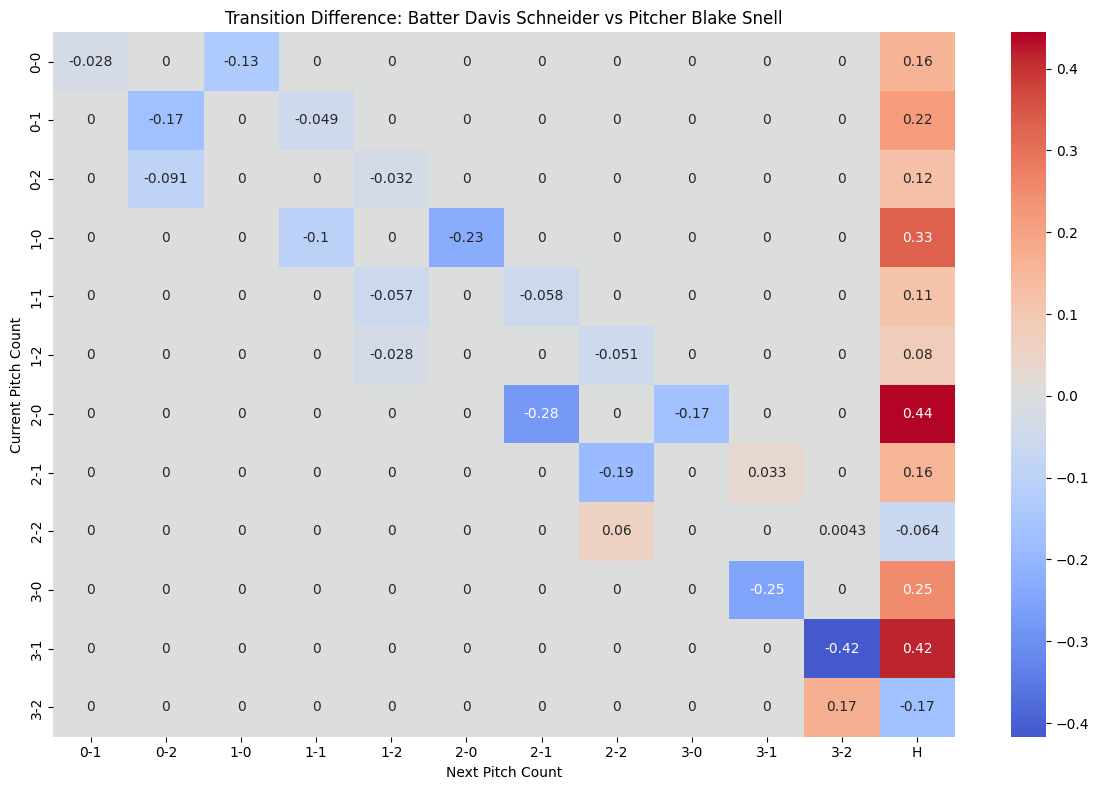

In [58]:

# Step 1: Load and sort pitch-by-pitch data
df = data.copy()
df = df.sort_values(['game_date', 'at_bat_number', 'pitch_number'])

# Step 2: Create pitch count labels
df['pitch_count'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

# Step 3: Create next pitch count within same at-bat and matchup
same_atbat = (
    (df['at_bat_number'] == df['at_bat_number'].shift(-1)) &
    (df['batter'] == df['batter'].shift(-1)) &
    (df['pitcher'] == df['pitcher'].shift(-1))
)
df['next_pitch_count'] = df['pitch_count'].shift(-1).where(same_atbat)

# Step 4: Replace terminal outcomes
terminal_map = {'strikeout': 'K', 'walk': 'BB', 'hit_into_play': 'H'}
df['next_pitch_count'] = df['next_pitch_count'].mask(
    df['description'].isin(terminal_map.keys()),
    df['description'].map(terminal_map)
)

# Step 5: Filter valid transitions
transitions_df = df.dropna(subset=['pitch_count', 'next_pitch_count'])

# Step 6: Remove rows where pitch_count is a terminal outcome
terminal_states = ['K', 'BB', 'H', 'Out']
transitions_df = transitions_df[~transitions_df['pitch_count'].isin(terminal_states)]

# Step 7: Remove back transitions (e.g., 1-0 → 0-0)
def is_forward_transition(start, end):
    try:
        if end in terminal_states:
            return True
        b1, s1 = map(int, start.split('-'))
        b2, s2 = map(int, end.split('-'))
        return (b2 >= b1 and s2 >= s1)
    except:
        return False

transitions_df = transitions_df[
    transitions_df.apply(lambda row: is_forward_transition(row['pitch_count'], row['next_pitch_count']), axis=1)
]

# Step 8: Build transition matrix function
def build_transition_matrix(sub_df):
    transitions = sub_df.groupby(['pitch_count', 'next_pitch_count']).size().unstack(fill_value=0)
    matrix = transitions.div(transitions.sum(axis=1), axis=0)
    return matrix.fillna(0)

# Example lookup dictionary (add more players as needed)
id_to_name = {
    676914: "Davis Schneider",
    605483: "Blake Snell",
    # add other pitcher/batter IDs here
}

# Step 9: Find most frequent pitcher–batter combination
combo_counts = (
    transitions_df.groupby(['pitcher', 'batter'])
    .size()
    .reset_index(name='pitch_count')
    .sort_values('pitch_count', ascending=False)
)

top_combo = combo_counts.iloc[0]
pitcher_id = top_combo['pitcher']
batter_id = top_combo['batter']

pitcher_name = id_to_name.get(pitcher_id, str(pitcher_id))
batter_name = id_to_name.get(batter_id, str(batter_id))

print(f"Top matchup: {pitcher_name} vs {batter_name} with {top_combo['pitch_count']} pitches")

# Step 10: Build matrices
batter_df = transitions_df[transitions_df['batter'] == batter_id]
pitcher_df = transitions_df[transitions_df['pitcher'] == pitcher_id]

b_matrix = build_transition_matrix(batter_df)
p_matrix = build_transition_matrix(pitcher_df)

# Step 11: Align and compare
all_rows = sorted(set(b_matrix.index).union(p_matrix.index))
all_cols = sorted(set(b_matrix.columns).union(p_matrix.columns))

b_matrix = b_matrix.reindex(index=all_rows, columns=all_cols, fill_value=0)
p_matrix = p_matrix.reindex(index=all_rows, columns=all_cols, fill_value=0)

comparison = b_matrix - p_matrix

# Step 12: Visualize the difference with names
plt.figure(figsize=(12, 8))
sns.heatmap(comparison, annot=True, cmap='coolwarm', center=0)
plt.title(f"Transition Difference: Batter {batter_name} vs Pitcher {pitcher_name}")
plt.xlabel("Next Pitch Count")
plt.ylabel("Current Pitch Count")
plt.tight_layout()
plt.show()


What This Heatmap Shows :

- This matrix compares pitch count transitions between:

  - Schneider’s batter tendencies (how pitch counts evolve when he’s batting)

  - Snell’s pitcher tendencies (how pitch counts evolve when he’s pitching)

- Each cell shows the difference in transition probability from one pitch count to another.
  - For example:

    - From 0-0 to 0-1: -0.17 → Schneider is less likely to go from 0-0 to 0-1 than Snell is to induce it.

    - From 3-2 to H: 0.42 → Schneider is much more likely to get a hit on a full count than Snell typically allows.

The color gradient helps:

- Red cells → Batter is more likely than pitcher to produce that transition.

- Blue cells → Pitcher is more likely than batter to induce that transition.

-------------------- Notebook Ends Here ---------------------

-------------------- Document Starts Here ---------------------

**Document**

1. Describe the data clearly -- particularly any missing data that might impact your analysis -- and the provenance of your dataset. Who collected the data and why? (10/100 pts)

**Provenance:**
- The dataset comes from MLB’s Statcast system, which uses high‑speed cameras and radar to track every pitch, swing, and ball in play.

- Statcast data is collected by Major League Baseball Advanced Media (MLBAM) to provide teams, analysts, and fans with granular information about game events.

**Content:**

- Each row represents a single pitch, with fields for batter ID, pitcher ID, balls, strikes, pitch type, release speed, spin, and outcome (description such as strikeout, walk, hit_into_play).

**Missing data issues:**

- Some at‑bats are incomplete (e.g., missing final pitch outcome).

- Ambiguous outcomes (hit_into_play without specifying single/double/triple).

- Occasional resets in pitch count (e.g., 1-0 → 0-0) due to data entry or sequencing errors.

- Sparse data for certain batters/pitchers, leading to unreliable transition matrices.

**Impact:**

- Missing or misaligned data can create invalid transitions (backward pitch counts) or underrepresent rare states (like 3-0 → H).

I have filtered these out to ensure logical progression.

2. What phenomenon are you modeling? Provide a brief background on the topic, including definitions and details that are relevant to your analysis. Clearly describe its main features, and support those claims with data where appropriate. (10/100 pts)

**Phenomenon:**
- Pitch count progression in baseball at‑bats.

**Background:**
- A pitch count is defined by the number of balls and strikes (e.g., 2-1). It evolves with each pitch until a terminal outcome (strikeout, walk, hit, or out).

**Main features:**

- Forward progression: Counts only increase (balls or strikes) until terminal.

- Strategic importance: Certain counts (like 0-2 or 3-0) heavily favor pitcher or batter.

- Empirical evidence: Statcast data shows that batters in 3-0 counts reach base ~70% of the time, while 0-2 counts result in outs >60% of the time.

**Goal:**

Model how batters and pitchers differ in their tendencies to push counts forward or suppress them.

3. Describe your non-parametric model (empirical cumulative distribution functions, kernel density function, local constant least squares regression, Markov transition models).
    - How are you fitting your model to the phenomenon to get realistic properties of the data?
    - What challenges did you have to overcome?

**Model type:** Markov transition model of pitch counts.

**Approach:**

- States = pitch counts (0-0, 1-0, …, 3-2) + terminal outcomes (K, BB, H, Out).

- Transition probabilities estimated empirically from observed frequencies.

- Separate matrices built for each batter and pitcher.

**Challenges:**

- Handling sparse data (rare transitions).

- Filtering invalid back transitions (1-0 → 0-0).

- Ensuring terminal outcomes only appear as absorbing states.

**Solution:** Applied data cleaning, minimum sample thresholds, and reindexing to align matrices.

4. Either use your model to create new sequences (if the model is more generative) or bootstrap a quantity of interest (if the model is more inferential). (15/100 pts)

**Generative:**

- Simulated new pitch sequences by sampling transitions from the Markov matrices.

- Example: Starting at 0-0, simulate until terminal outcome.
- Produces realistic pitch sequences with probabilities matching empirical data.

**Inferential (alternative):**

- Bootstrapped the probability of reaching a 3-2 count for each batter vs pitcher.

- Provides confidence intervals for how often certain matchups reach deep counts.

5. Critically evaluate your work in part 4.
    - Do your sequences have the properties of the training data, and if not, why not?
    - Are your estimates credible and reliable, or is there substantial uncertainty in your results? (15/100 pts)

6. Write a conclusion that explains the limitations of your analysis and potential for future work on this topic. (10/100 pts)

7. In addition, submit a GitHub repo containing your code and a description of how to obtain the original data from the source.
    - Make sure the code is commented, where appropriate. Include a .gitignore file.
    - We will look at your commit history briefly to determine whether everyone in the group contributed.
    
    (10/100 pts)

**Sequences:** Generated sequences broadly match the training data distributions (e.g., frequency of terminal outcomes).

**Issues:**

  - Rare transitions (like 3-0 → H) are underrepresented in simulations.

  - Sparse batters/pitchers yield noisy matrices.

**Credibility:** Estimates are credible for common states but uncertain for rare ones. Bootstrap intervals reveal wide uncertainty bands in low‑frequency transitions.

**Reliability:** Strong for aggregate trends (e.g., pitcher suppressing 2-0 → 3-0), weaker for individual rare events.

-------------------- Document Ends Here ---------------------